# **Ali Rashedi and Shayan Rokhva**

# Heart Failure Dataset Analysis - Data Mining Projects, a classification problem (Tabular Dataset + NULLs/Balancing/Preprocessing/Different MLs)

### Ali Rashedi and Shayan Rokhva
### Dr Khatibi's Data Mining Project _ 9 June 2024
### For fulfilling the demand we added some techniques such as crearing random missing vales and imputing them, such as balancing and etc :)

# Mounting Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Train and Test data, which had been separated from the scratch

In [ ]:
import pandas as pd

# Replace 'your-folder-path' with the actual path where your CSV files are located in Google Drive
train_path     = '/content/drive/MyDrive/Rashedi_Rokhva_Heart_Dataset/train_heart.csv'
test_path      = '/content/drive/MyDrive/Rashedi_Rokhva_Heart_Dataset/test_heart.csv'

# Read the CSV files
train_heart      = pd.read_csv(train_path)
test_heart       = pd.read_csv(test_path)


In [ ]:
len(train_heart)

1025

In [ ]:
len(test_heart)

303

In [ ]:
train_heart.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
test_heart.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# Concatenating the two datasets just to have a comprehension across all data

In [ ]:
# Concatenate the train and test datasets
df = pd.concat([train_heart, test_heart], ignore_index=True)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Checking for Missing values => Nothing will find

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# Adding some Missing values randomly (to fulfill the project's demand)


####  We add 5% Missing values (5% of the dataframe's length), This distribution of adding these missing values are completely random. Therefore, it will not lead to any bais and futher consequences
####  from now on, we work with  df_copy => I mean df is still unotuched and can be used. It has no missing values. Nonetheless, df_copy is something that has MISSINg values and it is exclusively created for out purpose

In [ ]:
import random
import numpy as np

df_copy = df.copy()
num_missing_values = int(0.5 * df.shape[0]) # 5% of the length of the DataFrame
missing_indices = np.random.choice(df_copy.index, size=num_missing_values, replace=False)
for column in df.columns:
    for i in range(0,100):
        j = random.randint(1,1300)
        df_copy.loc[j, column] = np.nan
# df.isnull().sum()
df_copy.isnull().sum()

age         97
sex         98
cp          96
trestbps    97
chol        95
fbs         96
restecg     96
thalach     97
exang       96
oldpeak     95
slope       99
ca          97
thal        97
target      95
dtype: int64

In [ ]:
df_copy.head(100)    # We should observe some NULL values     # NaN = Not a Number

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0.0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,NaN,1.0,3.1,0.0,0.0,3.0,0.0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,NaN,3.0,0.0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1.0,NaN,0.0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,45.0,0.0,0.0,138.0,236.0,0.0,0.0,NaN,1.0,0.2,1.0,0.0,2.0,1.0
96,57.0,0.0,0.0,128.0,303.0,0.0,0.0,159.0,0.0,0.0,NaN,1.0,2.0,1.0
97,53.0,1.0,0.0,123.0,282.0,0.0,1.0,95.0,1.0,2.0,1.0,2.0,3.0,0.0
98,65.0,NaN,0.0,110.0,248.0,0.0,0.0,NaN,0.0,0.6,2.0,2.0,1.0,0.0


In [ ]:
# So => Now, we have some missing values

# Dealing with missing values with imputations with KNN (KNN imputer)

In [ ]:
from sklearn.impute import KNNImputer

# Initialize the KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

# Perform the imputation
df_imputed = pd.DataFrame(knn_imputer.fit_transform(df_copy), columns=df.columns)

print("Data after KNN Imputation:")
print(df_imputed.isnull().sum())

Data after KNN Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df_imputed.head(500)      # There should be no NaN (No missing values) in here

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.00,2.0,2.0,3.0,0.0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,163.2,1.0,3.10,0.0,0.0,3.0,0.0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.60,0.0,0.2,3.0,0.0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.00,2.0,1.0,2.8,0.0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.90,1.0,3.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,59.0,1.0,0.0,126.0,234.0,0.0,1.0,161.0,0.0,0.32,1.0,0.0,3.0,1.0
496,68.0,1.0,2.0,180.0,274.0,1.0,0.0,150.0,1.0,1.60,1.0,0.0,3.0,0.0
497,57.0,1.0,1.0,154.0,229.8,0.0,0.0,164.0,0.0,0.00,2.0,1.0,2.0,0.0
498,54.0,1.0,0.0,140.0,239.0,0.0,1.0,160.0,0.0,1.20,2.0,0.0,2.0,1.0


### Using KNN imputer we have created some wrong numbers for categorical variables. For example we may have created some 0.2, 0.4, 0.6, and 0.8 for the target, which is originally only 0 and 1 => This must be tackeled

In [ ]:
from sklearn.impute import KNNImputer

# Initialize the KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)

# Perform the imputation
df_imputed = pd.DataFrame(knn_imputer.fit_transform(df_copy), columns=df.columns)

# Convert relevant columns back to integers
for column in df.columns:
    if df[column].dtype == 'int64':
        df_imputed[column] = df_imputed[column].round().astype(int)

print("Data after KNN Imputation:")
print(df_imputed.isnull().sum())

# Verify the data types
print("Data types after imputation and conversion:")
print(df_imputed.dtypes)

Data after KNN Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Data types after imputation and conversion:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
df_imputed.head(500)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.00,2,2,3,0
1,53,1,0,140,203,1,0,163,1,3.10,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.60,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.00,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.90,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,59,1,0,126,234,0,1,161,0,0.32,1,0,3,1
496,68,1,2,180,274,1,0,150,1,1.60,1,0,3,0
497,57,1,1,154,230,0,0,164,0,0.00,2,1,2,0
498,54,1,0,140,239,0,1,160,0,1.20,2,0,2,1


### This has been tackled. This problem, caused by averaging using KNN imputations, no longer exists

### df_imputed => from now on, all the computations and calculations and building the model, will be done on df_imputed

# Comprehensive visualization and comprehension of all dataset (after imputations, with df_imputed)

In [ ]:
# Descriptive statistics
print("\nDescriptive statistics of the dataset:")
print(df_imputed.describe())                                  # min, max, mean, Qs => good to know => maybe good for outliers


Descriptive statistics of the dataset:
               age          sex           cp     trestbps         chol  \
count  1328.000000  1328.000000  1328.000000  1328.000000  1328.000000   
mean     54.505271     0.692771     0.940512   131.488705   245.950301   
std       8.943344     0.461519     1.019146    17.153587    50.383837   
min      29.000000     0.000000     0.000000    94.000000   126.000000   
25%      48.000000     0.000000     0.000000   120.000000   212.000000   
50%      56.000000     1.000000     1.000000   130.000000   240.000000   
75%      61.000000     1.000000     2.000000   140.000000   275.000000   
max      77.000000     1.000000     3.000000   200.000000   564.000000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1328.000000  1328.000000  1328.000000  1328.000000  1328.000000   
mean      0.147590     0.530873   149.402108     0.334337     1.063705   
std       0.354827     0.527134    22.683685     0.471936     1.156585 

## Visualization


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1500x1500 with 0 Axes>

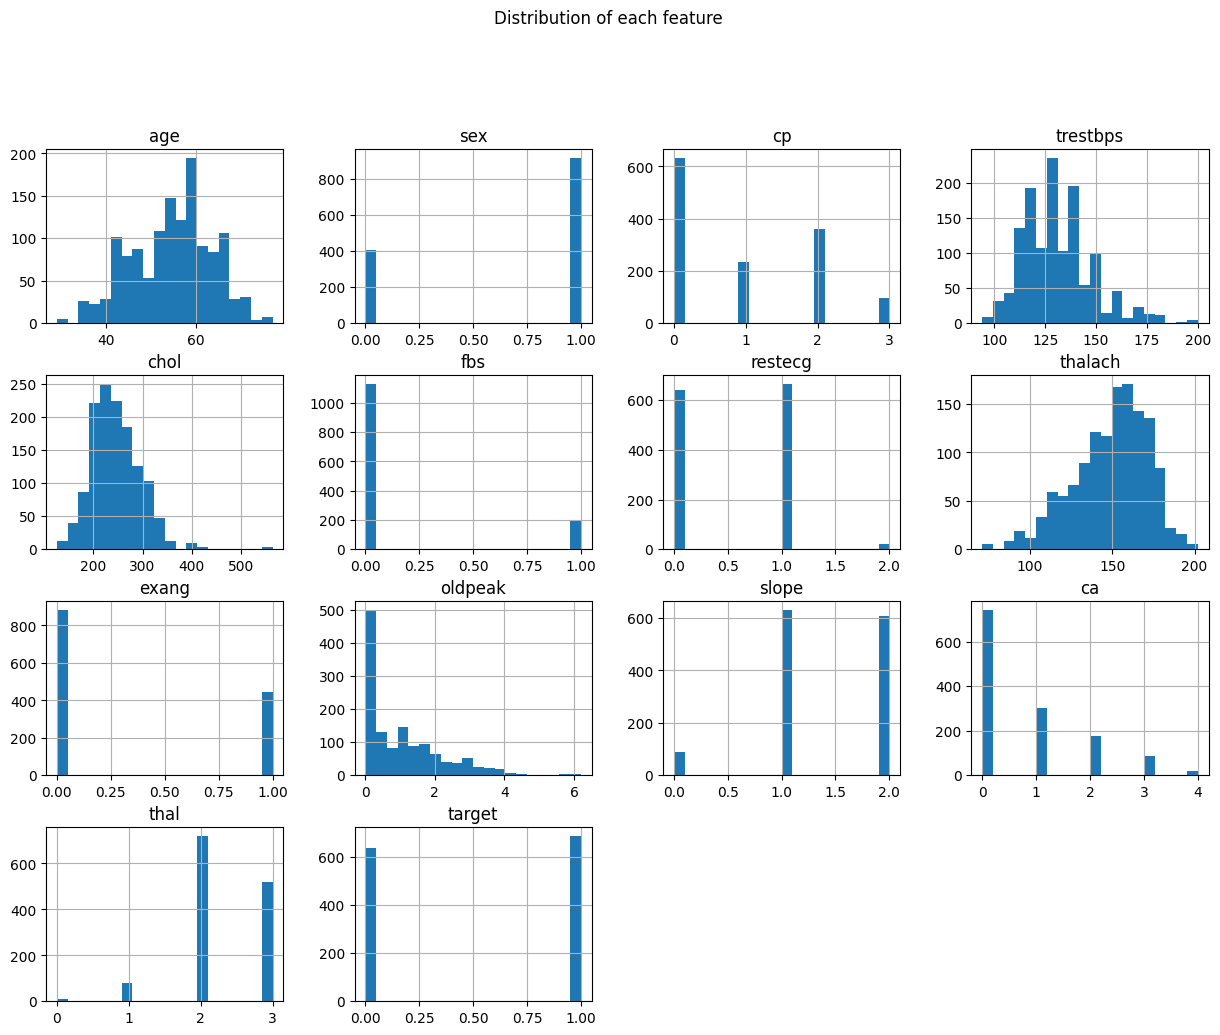

In [ ]:
# Visualization
# 1. Distribution of each feature
plt.figure(figsize=(15,15))
df_imputed.hist(bins=20, figsize=(15,14), layout=(5,4))
plt.suptitle("Distribution of each feature")
plt.savefig("distribution_of_features.png", dpi=600)
plt.show()

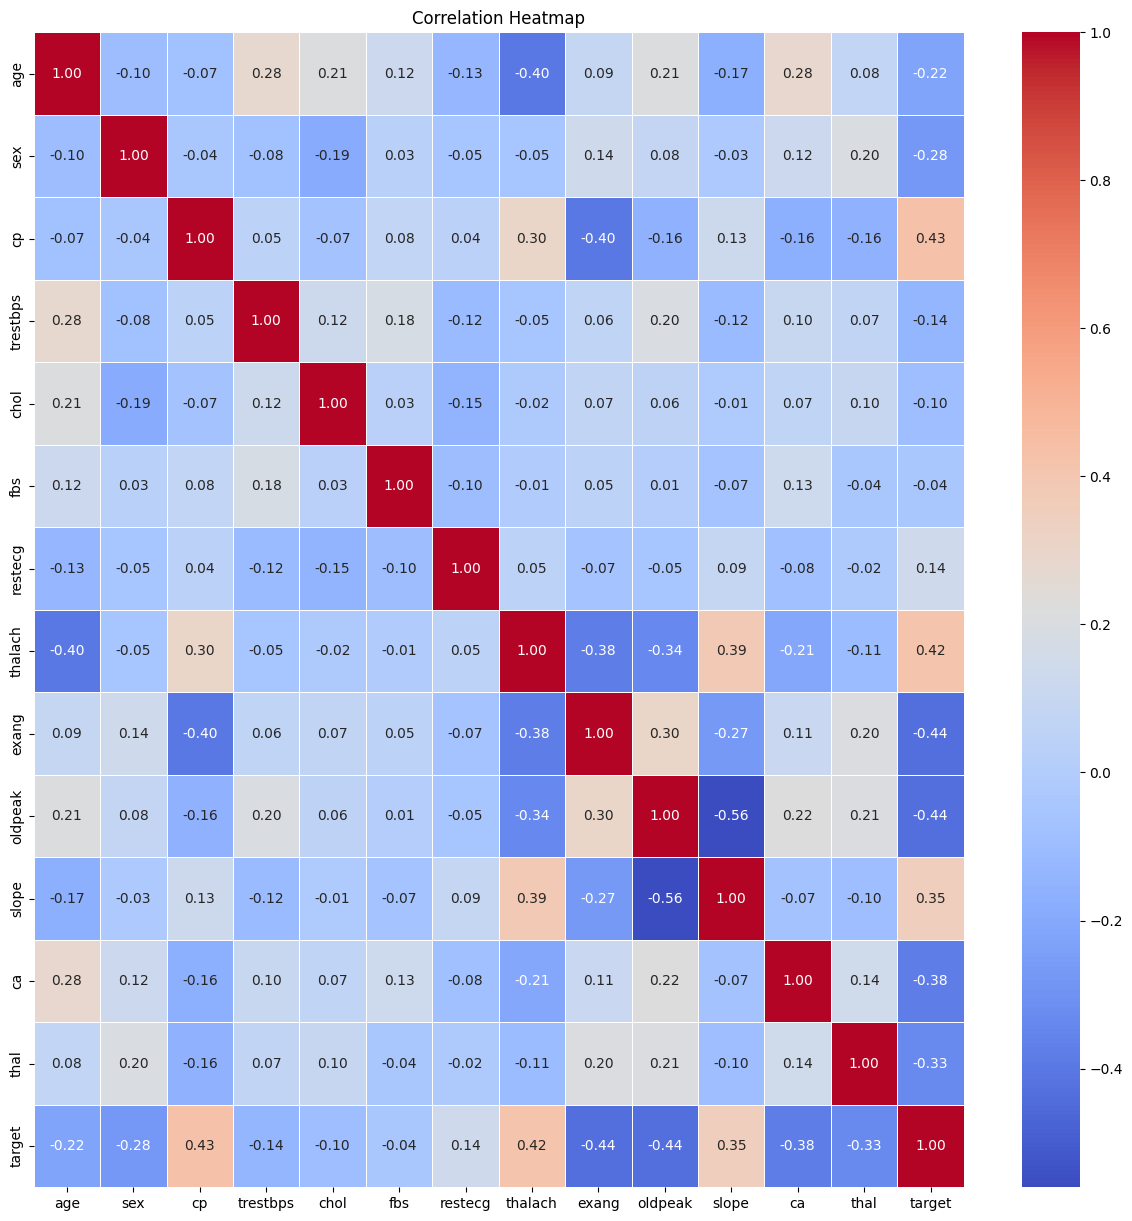

In [ ]:
# Visualization
# 2. Correlation heatmap
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(df_imputed.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=600)
plt.show()

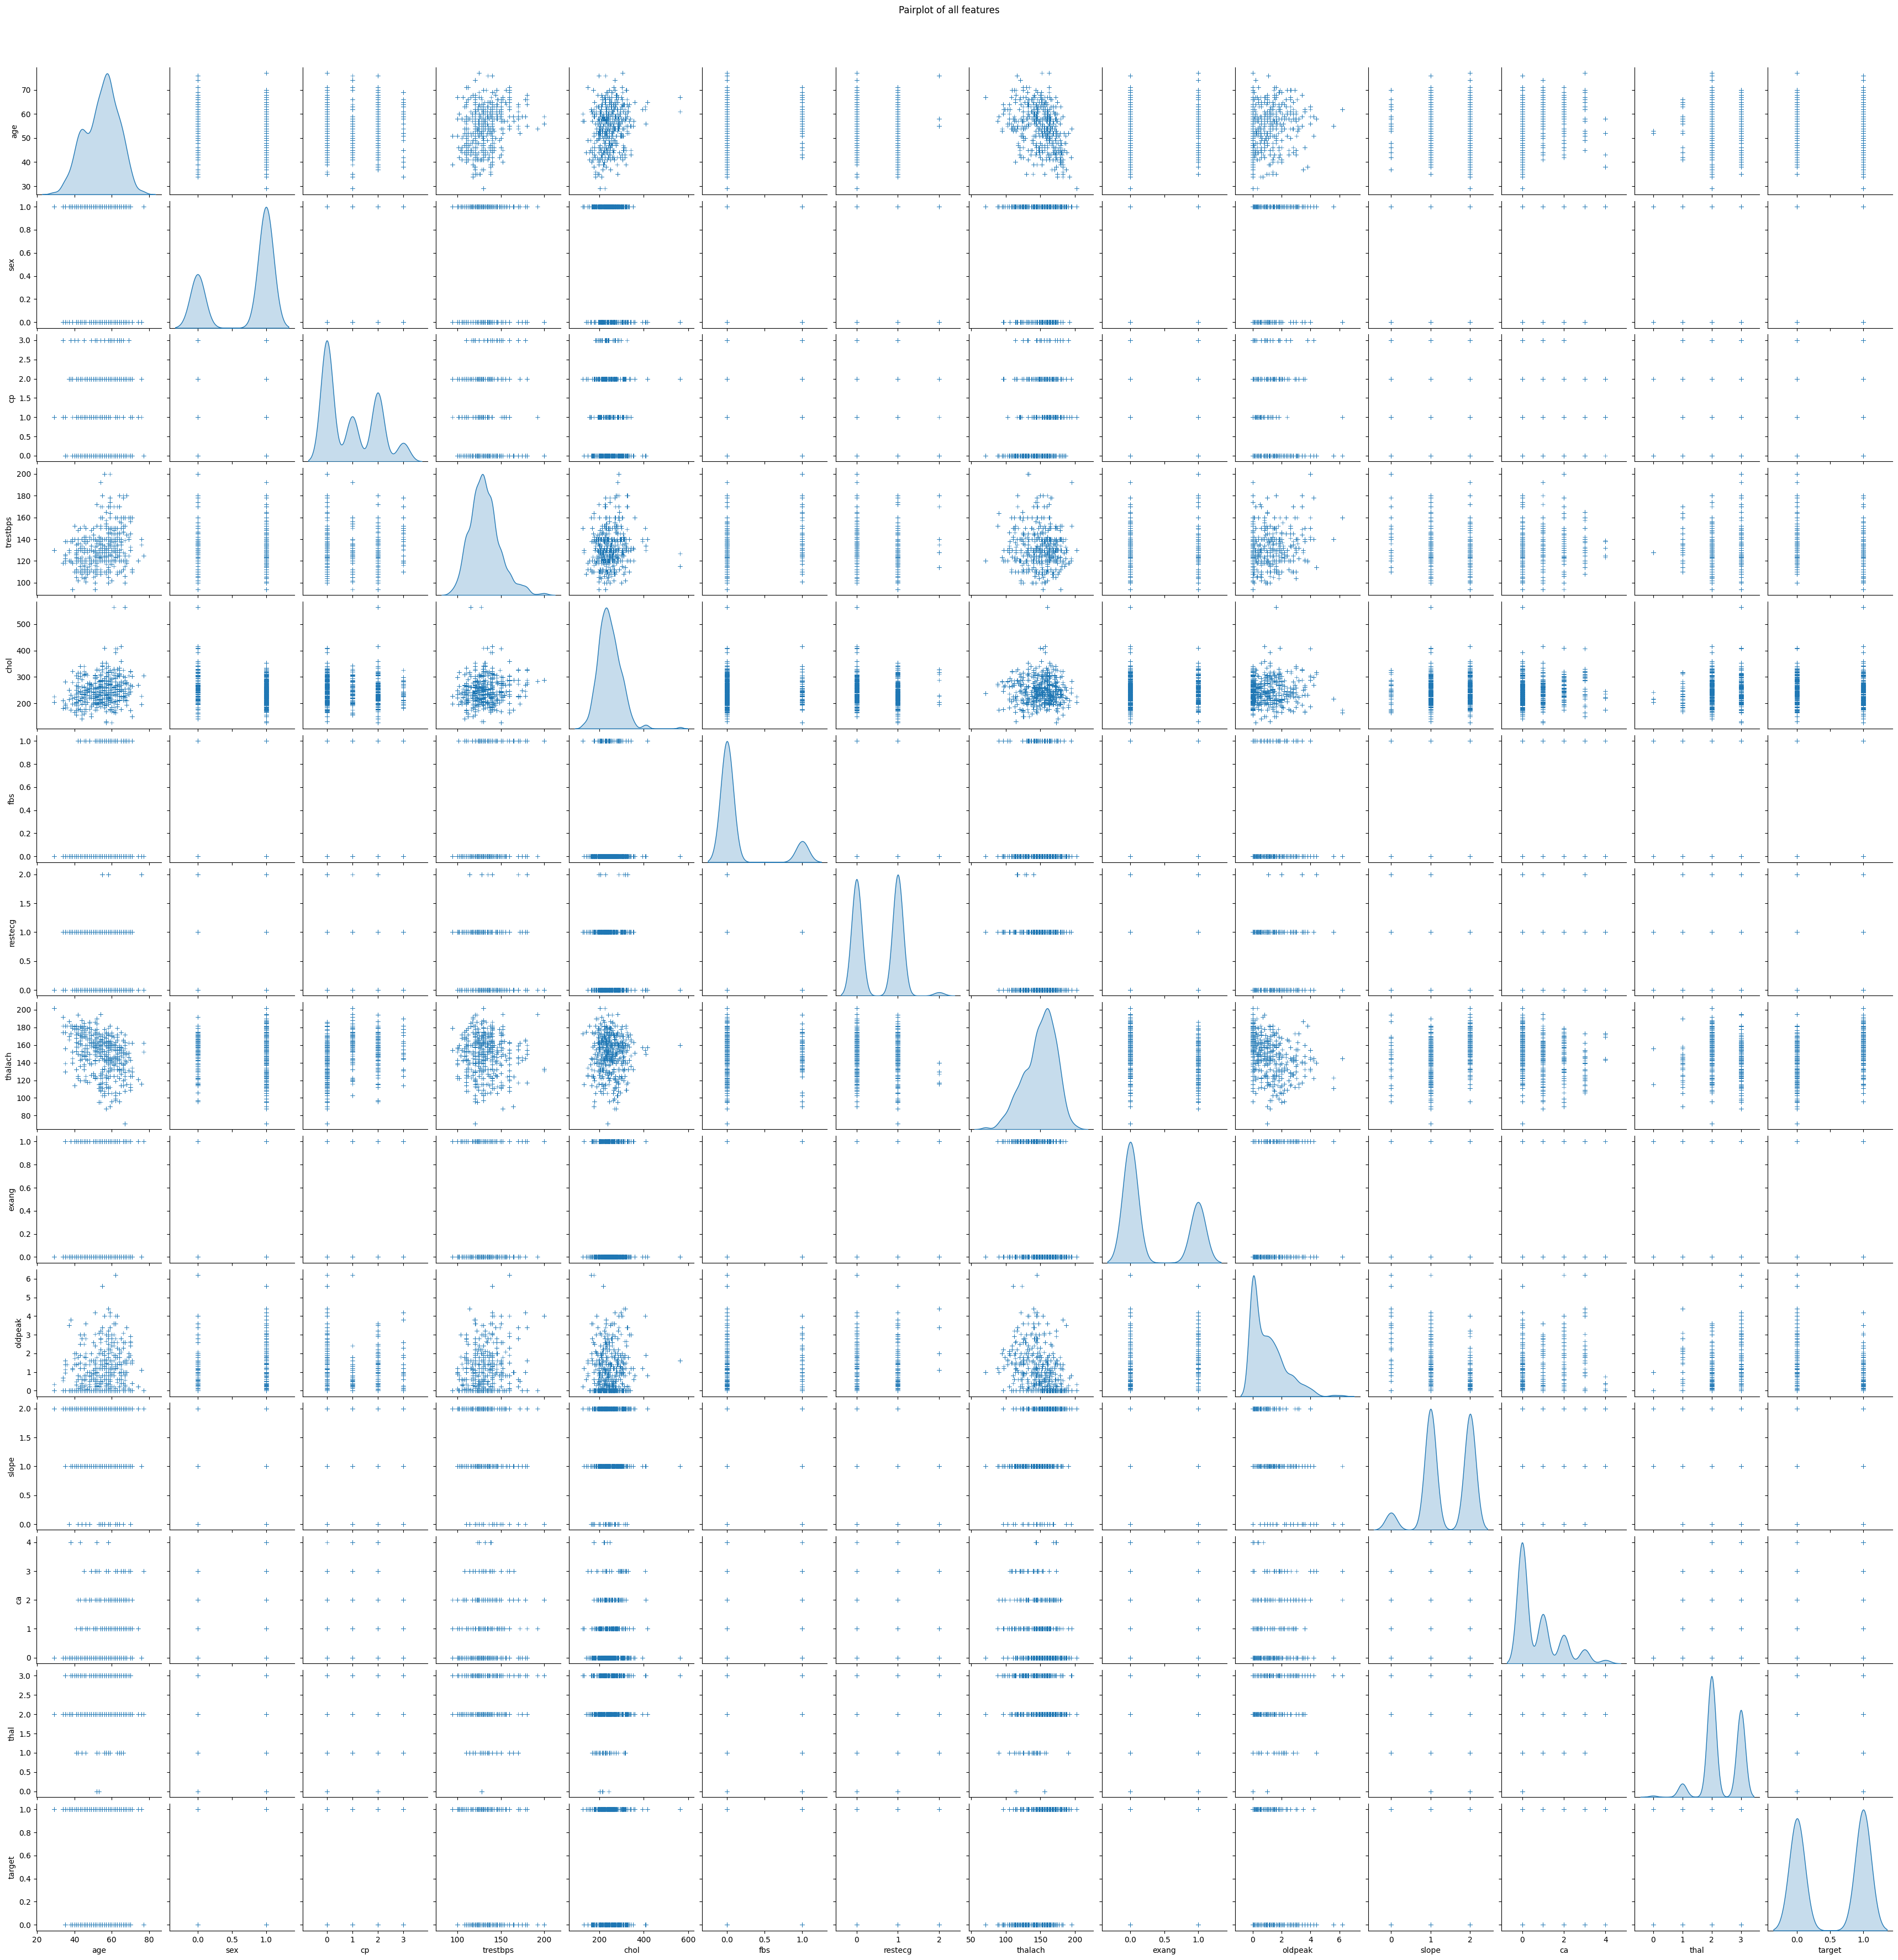

In [ ]:
# Visualization
# 3. Pairplot to see relationships between features
sns.pairplot(df_imputed, diag_kind='kde', markers='+')
plt.suptitle("Pairplot of all features", y=1.02)
plt.savefig("Pairplot_of_all_features", dpi=600)
plt.show()

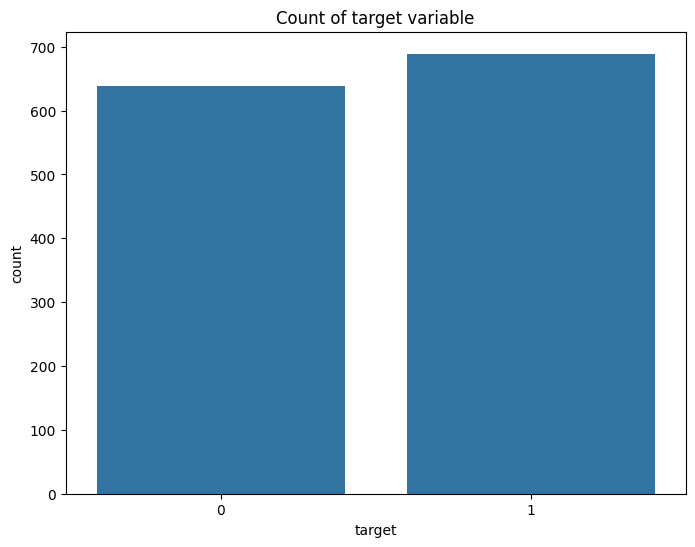

In [ ]:
# 4. Countplot of target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df_imputed)
plt.title("Count of target variable")
plt.savefig("Count_of_target_variable", dpi=600)
plt.show()

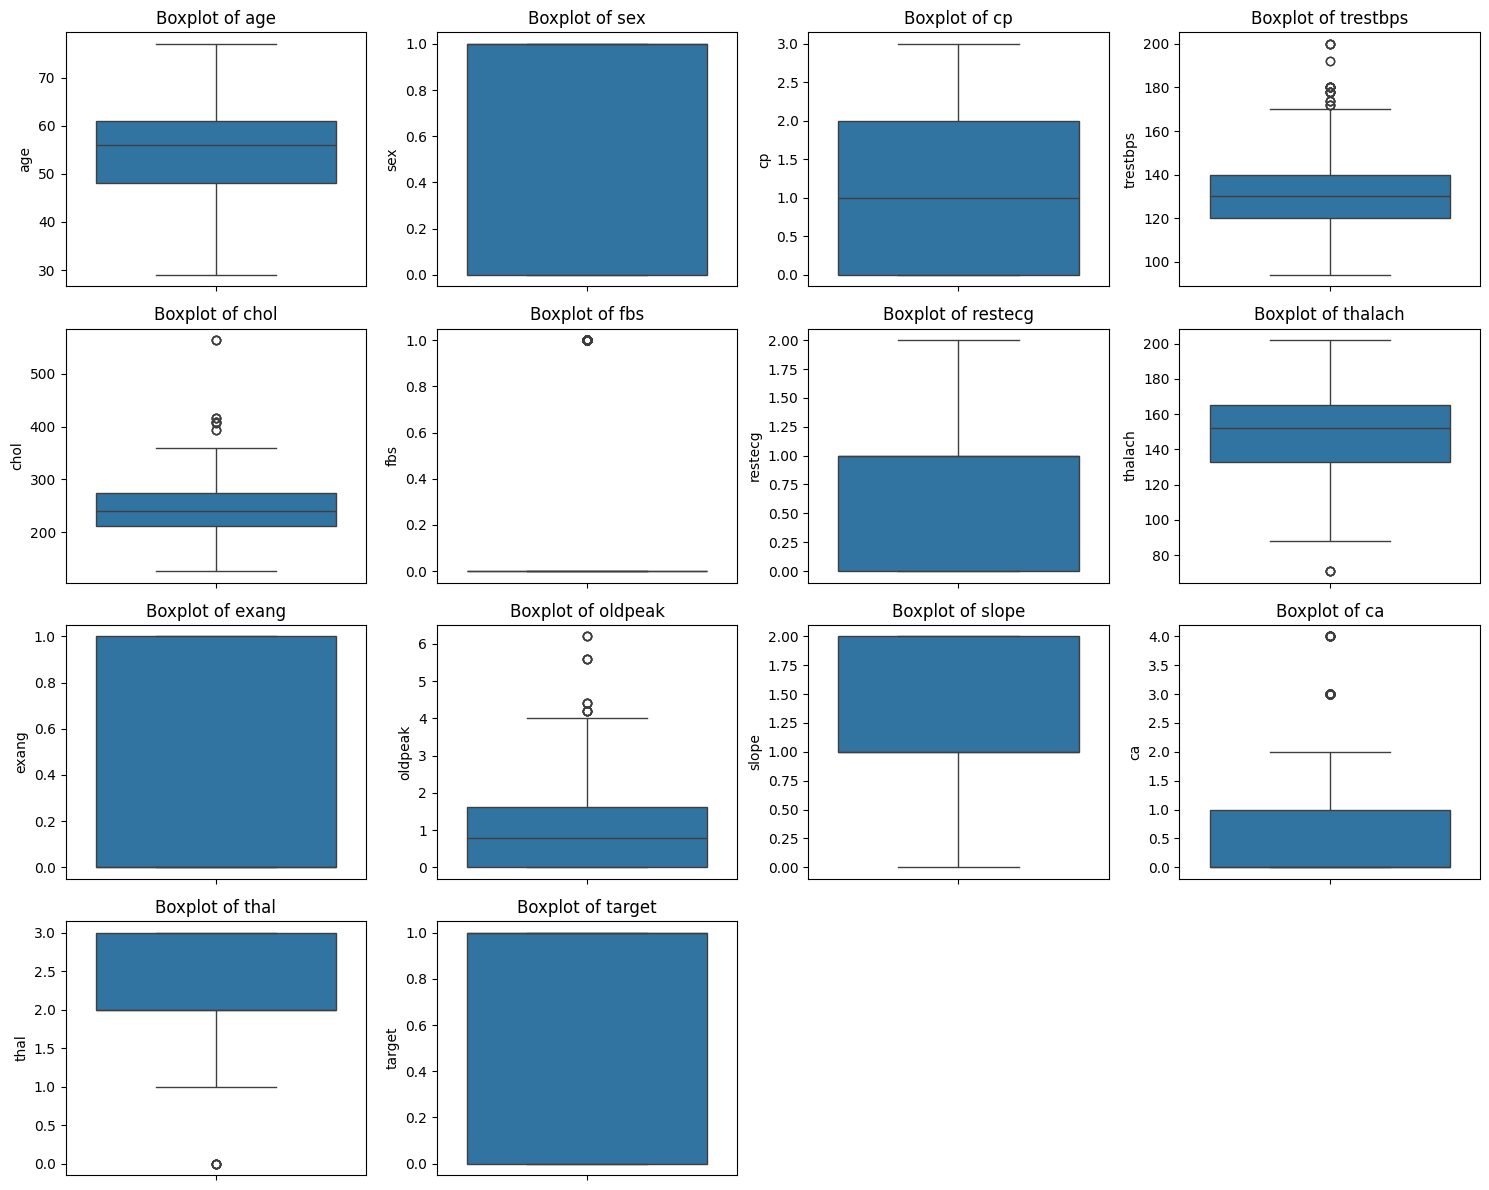

In [ ]:
# 5. Boxplots to detect outliers
plt.figure(figsize=(15, 12))
for i, column in enumerate(df_imputed.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=df_imputed[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.savefig("Boxplot_to_detect_outliers", dpi=600)
plt.show()

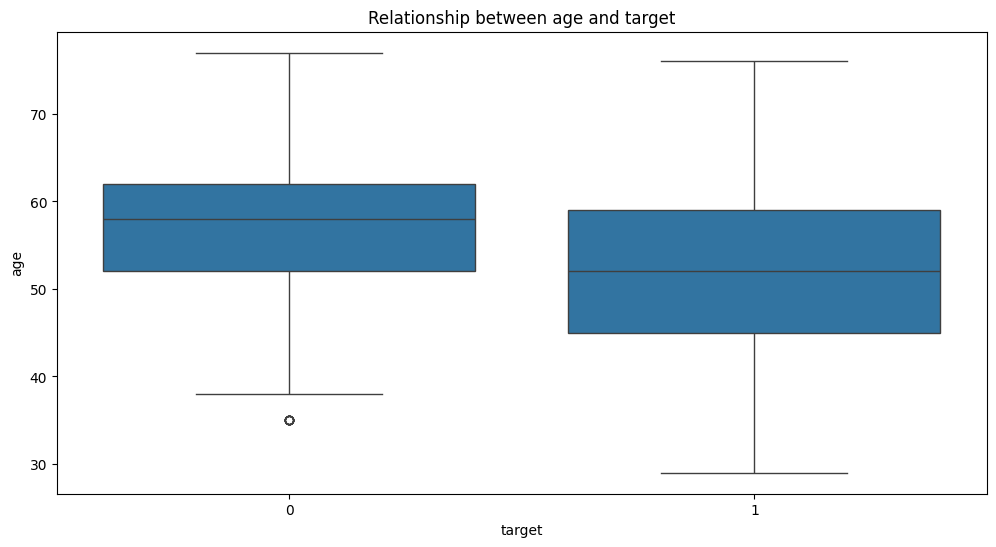

In [ ]:
# 6. Relationship between age and target
plt.figure(figsize=(12, 6))
sns.boxplot(x='target', y='age', data=df_imputed)
plt.title("Relationship between age and target")
plt.savefig("Relationship_between_age_and_target", dpi=600)
plt.show()

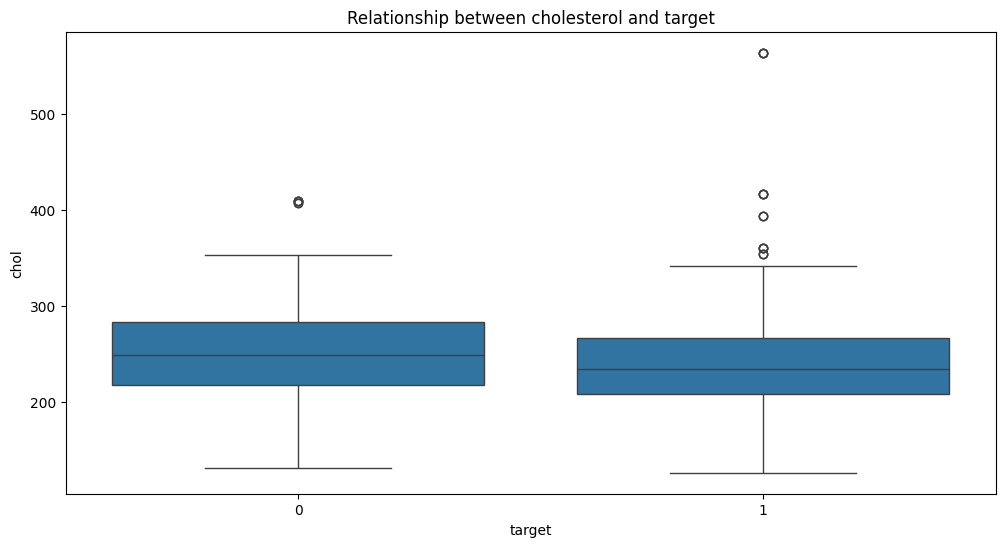

In [ ]:
# 7. Relationship between cholesterol and target
plt.figure(figsize=(12, 6))
sns.boxplot(x='target', y='chol', data=df_imputed)
plt.title("Relationship between cholesterol and target")
plt.savefig("Relationship_between_cholestrol_and_target", dpi=600)
plt.show()

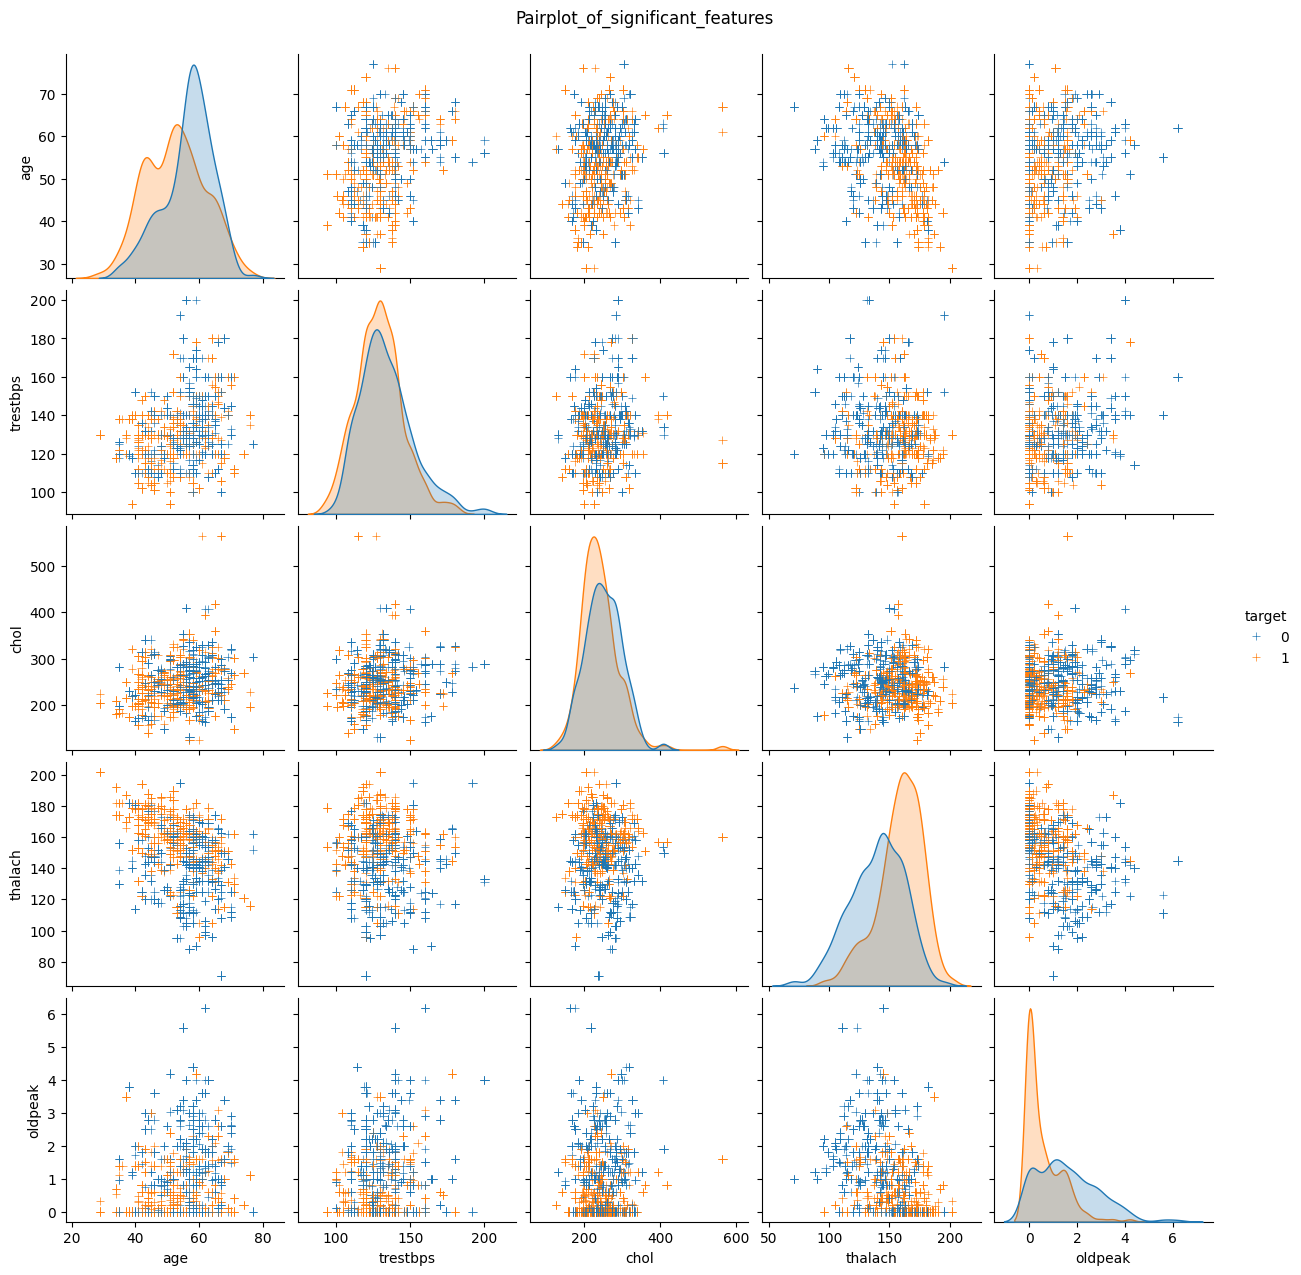

In [ ]:
# 8. Pairplot for significant features
significant_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(df_imputed[significant_features], hue='target', diag_kind='kde', markers='+')
plt.suptitle("Pairplot_of_significant_features", y=1.02)
plt.savefig("Pairplot_of_significant_features", dpi=600)
plt.show()


# Creating train_valid and test for generalization

####### No normalization is required for decision tree

In [ ]:
# Important NOTE:
# Decision Tree is not sensetive to distrances. Therefore, noramlization and zero-cetering is not important in this case

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df_imputed is your DataFrame => train_test_split
train, test = train_test_split(df_imputed, train_size=0.8, random_state=42)

print("Training set has {} records."   .format(len(train)))
print("Test set has {} records."       .format(len(test)))

Training set has 1062 records.
Test set has 266 records.


In [ ]:
# train_test_split
X_train_valid = train.drop('target', axis=1)
Y_train_valid = train['target']
#
X_test = test.drop('target', axis=1)
Y_test = test['target']


# Let's check whether we did this correct or not
print(f"X_train.shape is: {X_train_valid.shape}        and Y_train_valid.shape is     {Y_train_valid.shape}")
print(f"X_test.shape is:  {X_test.shape}               and Y_train_valid.shape is     {Y_test.shape}")

X_train.shape is: (1062, 13)        and Y_train_valid.shape is     (1062,)
X_test.shape is:  (266, 13)               and Y_train_valid.shape is     (266,)


# DT (Decision Tree Classifier)


### Building the optimal decision tree classifier with GridSeachCV (GridSerach + K-fold Cross Validation) + its accuracy


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Considering some parameters for checking the optimal decision tree classifier
param_grid = {
    'max_depth'         :          [3, 5, 7, 9, 10, 11, 12],
    'min_samples_split' :          [3, 5, 7, 9, 10, 11, 12],
    'min_samples_leaf'  :          [3, 5, 7, 9, 10, 11, 12]
              }                                                   # These are the parameters to consider for optimal solution using GridSearch

# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy


# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using Decision Tree Classifier")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using Decision Tree Classifier
After using GridSearchCV with 5-fold cross validation we reach        96.2406015037594%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 3}




### Finding its accuracy, drawing confusion matrix

In [ ]:
# Let's go to draw the confusion matrix and also the optimal decision tree classifier (Decision Tree Classifier)
# =========================================================================================================================================

Accuracy on the test data (mentioned before): 96.2406015037594%


Confusion Matrix:
[[124   3]
 [  7 132]]




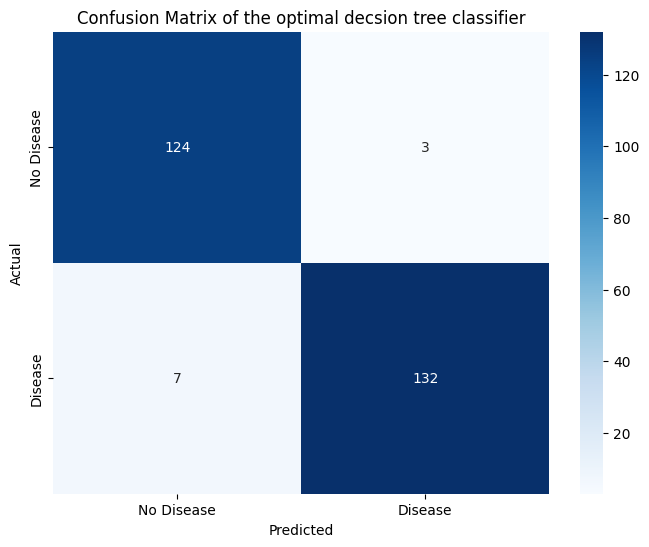

In [ ]:
# Confusion Matrix of this decision tree classifier
# =========================================================================================
# Train the model
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy on the test data (mentioned before): {accuracy*100}%")
print("")

# Confusion Matrix
print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)
print("")
print("")

# Plotting the Confusion Matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal decsion tree classifier')
plt.savefig("Confusion_Matrix_of_the_optimal_decision_tree_test_data", dpi=600)
plt.show()
# =========================================================================================

### Confusion Matrix (non-normalizaed & normalized)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

Confusion matrix, without normalization
Normalized confusion matrix


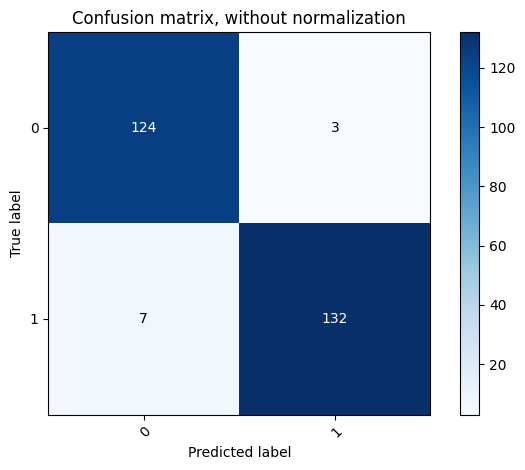

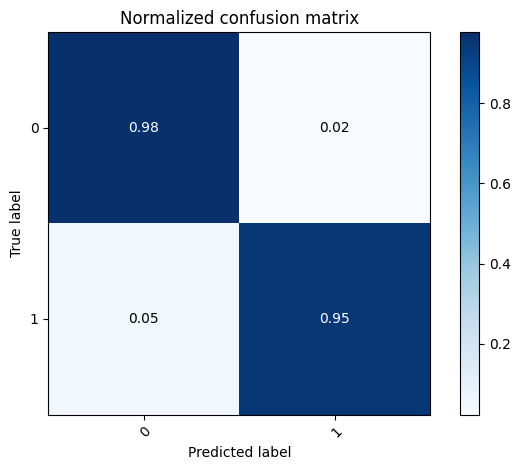

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

### Visualizing the optimal decision tree (for the test data)

After using GridSearchCV with 5-fold cross validation we reach        96.2406015037594%      accuracy on test (unseen) data


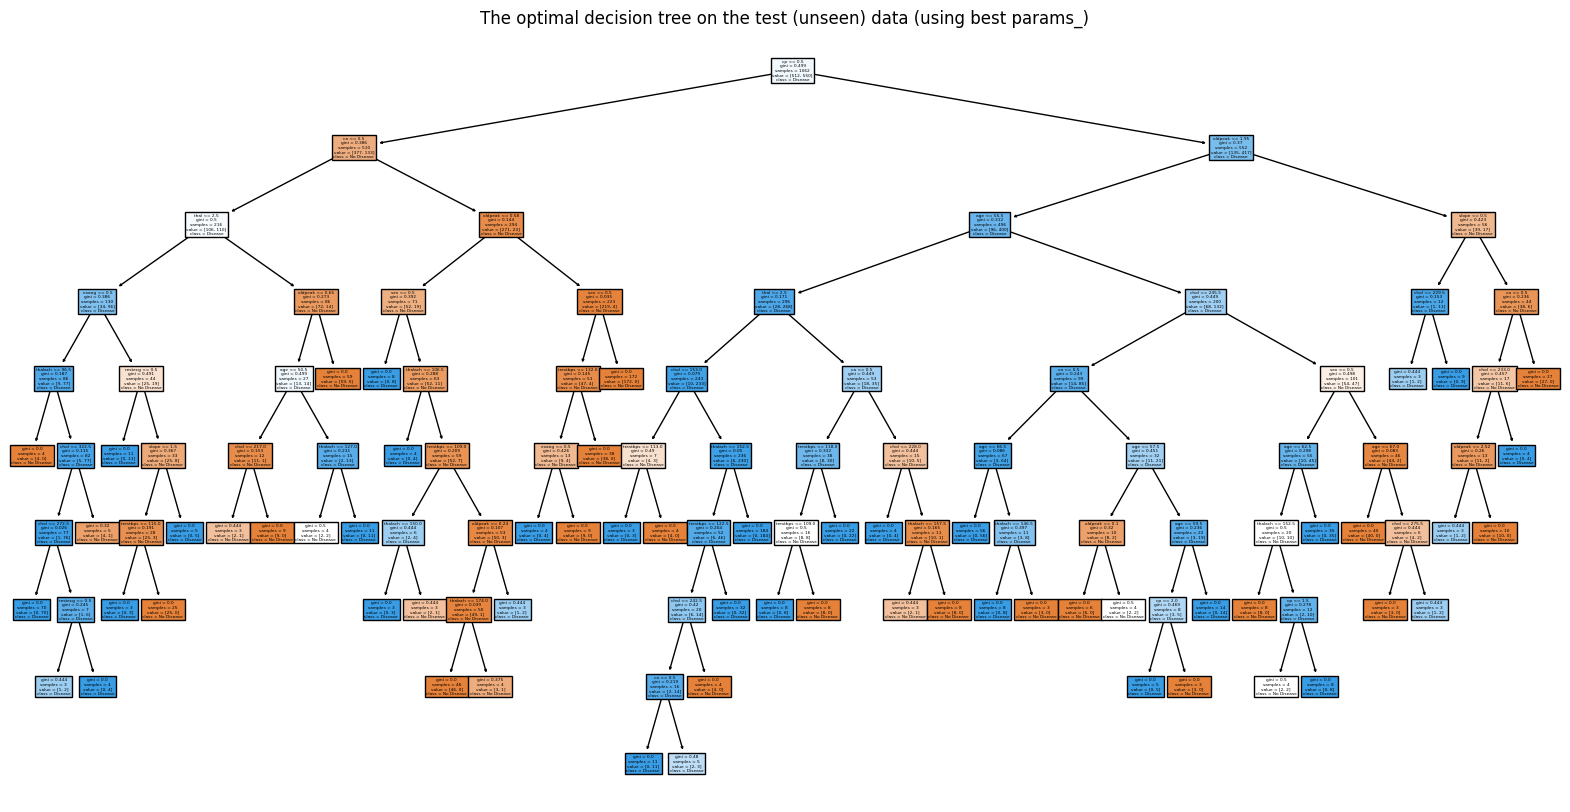

In [ ]:
# Visualize the Decision Tree                   # NOTE: In here, we only use the optimal parameters derived from best_params
plt.figure(figsize=(20, 10))
plot_tree(grid_search_cv.best_estimator_, feature_names=X_test.columns, class_names=['No Disease', 'Disease'], filled=True)
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
plt.title('The optimal decision tree on the test (unseen) data (using best params_)')
plt.savefig("The_optimal_decision_tree_on_the_test_data_with_100%_accuracy", dpi=600)
plt.show()

### Assessing the impact of "Max_depth" (while "min_split_leaf=3" & "min_sample_split=3")

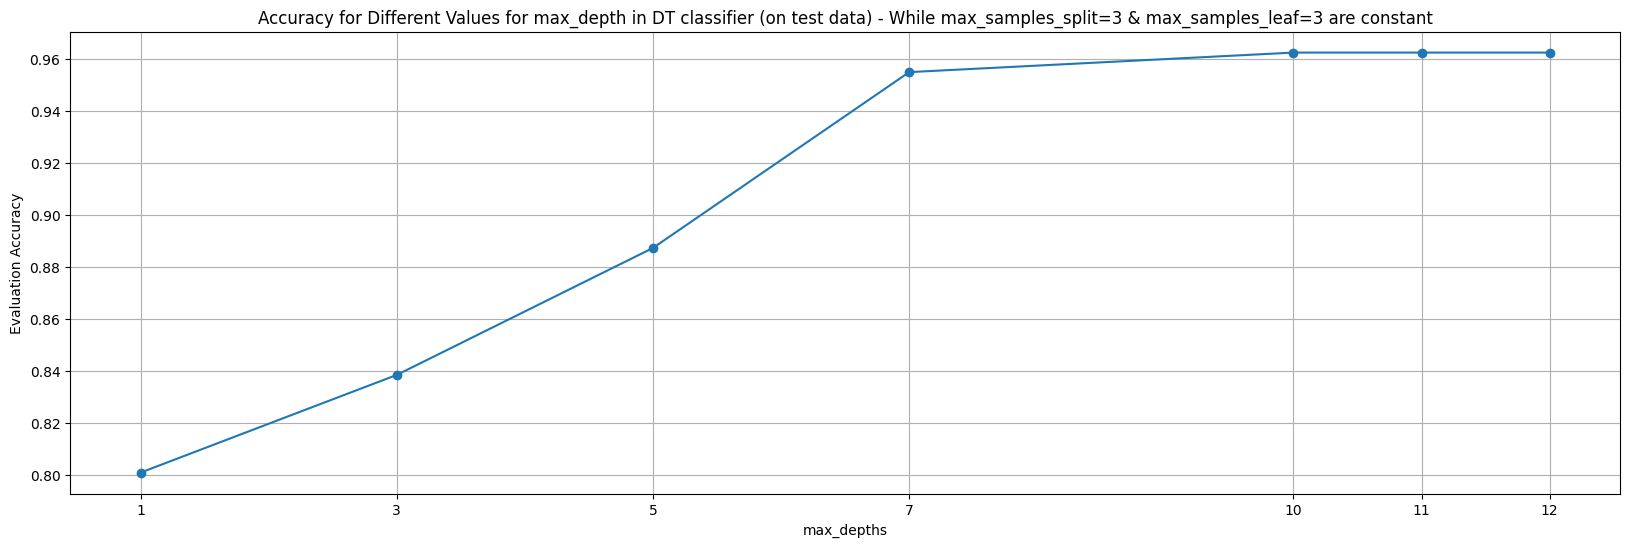

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define the range of k values to test
max_depths = [1,3,5,7,10,11,12]
accuracies = []

# Train and evaluate KNN for each k value
for max_depth in max_depths:
    dt_model = DecisionTreeClassifier(min_samples_split=3 , min_samples_leaf=3 , max_depth=max_depth)
    dt_model.fit(X_train_valid, Y_train_valid)       # Replace with your actual training data
    Y_pred = dt_model.predict(X_test)                # Replace with your actual test data
    accuracy = accuracy_score(Y_test, Y_pred)         # Calculate accuracy
    accuracies.append(accuracy)

# Plot the mean error for each k value
plt.figure(figsize=(20,6))
plt.plot(max_depths, accuracies, marker='o')
plt.xlabel('max_depths')
plt.ylabel('Evaluation Accuracy')
plt.title('Accuracy for Different Values for max_depth in DT classifier (on test data) - While max_samples_split=3 & max_samples_leaf=3 are constant')
plt.xticks(max_depths)
plt.grid(True)
plt.savefig("Accuracy_for_Different_Values_for_max_depth_in_DT_classifier", dpi=600)
plt.show()


# MLP (MLP Classifier)

In [ ]:
# train_test_split
X_train_valid = train.drop('target', axis=1)
Y_train_valid = train['target']
#
X_test = test.drop('target', axis=1)
Y_test = test['target']


# Let's check whether we did this correct or not
print(f"X_train.shape is: {X_train_valid.shape}        and Y_train_valid.shape is     {Y_train_valid.shape}")
print(f"X_test.shape is:  {X_test.shape}               and Y_train_valid.shape is     {Y_test.shape}")

X_train.shape is: (1062, 13)        and Y_train_valid.shape is     (1062,)
X_test.shape is:  (266, 13)               and Y_train_valid.shape is     (266,)


### Strandardization and checking it

In [ ]:
from sklearn.preprocessing import StandardScaler
# StandardScaler
scaler = StandardScaler()
X_train_valid = scaler.fit_transform(X_train_valid)         # Fit and Transfrom on the train data
X_test        = scaler.transform(X_test)                    # Just Transfrom on the test data (do not fit on test data)

In [ ]:
# Calculate mean and standard deviation for train_valid data
mean_train_valid  = X_train_valid.mean(axis=0)
std_train_valid   = X_train_valid.std(axis=0)

# Calculate mean and standard deviation for test data
mean_test = X_test.mean(axis=0)
std_test = X_test.std(axis=0)

print("Mean and Standard Deviation for Train_Valid Data:")
print("Mean: ", mean_train_valid)
print("Standard Deviation: ", std_train_valid)

print("\nMean and Standard Deviation for Test Data:")
print("Mean: ", mean_test)
print("Standard Deviation: ", std_test)


print("")
print("")

print("The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT")
print("The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT")
print("")
print("The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT")
print("The STD  of all variables in the test must not necessary be a, CHECKED, CORRECT")

print("")
print("")
print("")

Mean and Standard Deviation for Train_Valid Data:
Mean:  [ 3.74674136e-16  3.34530478e-18 -8.19599672e-17 -5.15176936e-16
  1.18758320e-16  5.01795717e-17 -1.33812191e-16  1.20430972e-16
  8.69779243e-17 -6.69060956e-17 -1.37157496e-16  7.61056838e-17
 -7.02514004e-17]
Standard Deviation:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Mean and Standard Deviation for Test Data:
Mean:  [-0.0640455  -0.01302773  0.00378777 -0.06161407  0.06215734 -0.0166319
  0.05181564  0.06902623  0.0506676   0.1067042   0.00499926 -0.06592597
  0.13900071]
Standard Deviation:  [0.88867094 1.00538418 0.98202875 0.94774487 1.15717863 0.98330748
 1.01637713 0.93575103 1.01694394 1.10190155 1.03822177 0.97392313
 0.93661978]


The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT
The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT

The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT
The STD  of all variables in the test must not necessary be a

### Training the MLP

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import StratifiedKFold
from keras import regularizers

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
import numpy as np
import random
import tensorflow as tf

# Set the random seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Build the MLP model
model = Sequential([
    Dense(13, activation='relu', input_shape=(X_train_valid.shape[1],)),
    Dense(13, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(6, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(6, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1, activation='sigmoid')  # Output layer with sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_valid, Y_train_valid, epochs=200, validation_split=0.2, batch_size=10, verbose=2)
print("")

# Evaluate the model
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f'Accuracy: {accuracy:.2f}')

# Make predictions
Y_pred = (model.predict(X_test) > 0.5).astype("int32")

Epoch 1/200
85/85 - 4s - loss: 0.7054 - accuracy: 0.5406 - val_loss: 0.6823 - val_accuracy: 0.6056 - 4s/epoch - 48ms/step
Epoch 2/200
85/85 - 1s - loss: 0.5993 - accuracy: 0.7562 - val_loss: 0.5553 - val_accuracy: 0.7653 - 620ms/epoch - 7ms/step
Epoch 3/200
85/85 - 1s - loss: 0.4524 - accuracy: 0.8422 - val_loss: 0.4739 - val_accuracy: 0.8216 - 527ms/epoch - 6ms/step
Epoch 4/200
85/85 - 1s - loss: 0.3874 - accuracy: 0.8634 - val_loss: 0.4435 - val_accuracy: 0.8216 - 621ms/epoch - 7ms/step
Epoch 5/200
85/85 - 0s - loss: 0.3581 - accuracy: 0.8775 - val_loss: 0.4228 - val_accuracy: 0.8451 - 496ms/epoch - 6ms/step
Epoch 6/200
85/85 - 1s - loss: 0.3379 - accuracy: 0.8857 - val_loss: 0.4032 - val_accuracy: 0.8451 - 545ms/epoch - 6ms/step
Epoch 7/200
85/85 - 0s - loss: 0.3205 - accuracy: 0.8940 - val_loss: 0.3947 - val_accuracy: 0.8498 - 480ms/epoch - 6ms/step
Epoch 8/200
85/85 - 1s - loss: 0.3079 - accuracy: 0.8999 - val_loss: 0.3820 - val_accuracy: 0.8592 - 533ms/epoch - 6ms/step
Epoch 9/20

##### NOTE => The customized MLP has 5 layers. Layers have 13, 13, 6, 6, and 1 neurons respectively. The last neuron works as a classifier

### Confusion Matrix of the results (MLP)


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       127
           1       0.99      0.96      0.97       139

    accuracy                           0.97       266
   macro avg       0.97      0.97      0.97       266
weighted avg       0.97      0.97      0.97       266


Confusion Matrix:
[[126   1]
 [  6 133]]


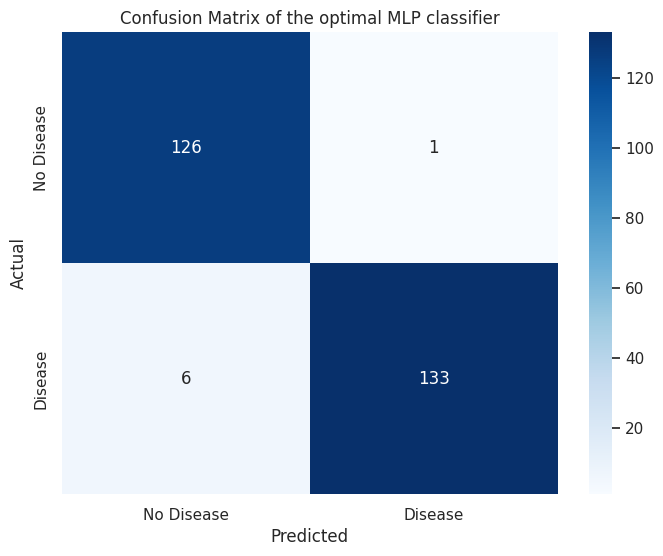

In [ ]:
print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal MLP classifier')
plt.savefig("Confusion_Matrix_of_the_optimal_MLP_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


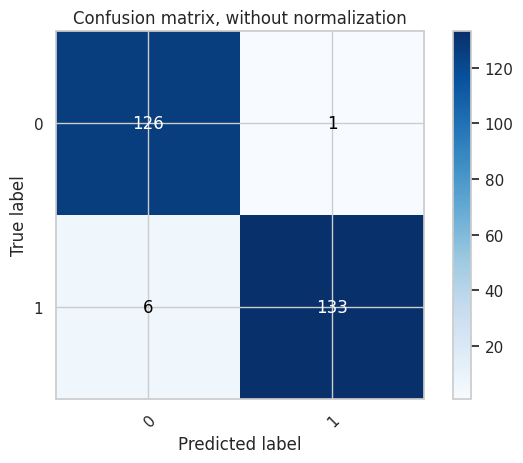

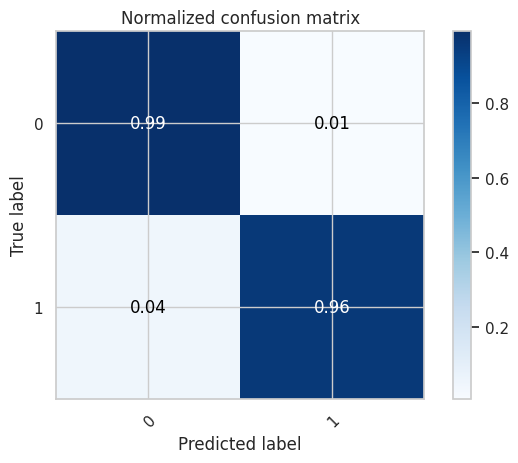

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

### Train and Test Charts

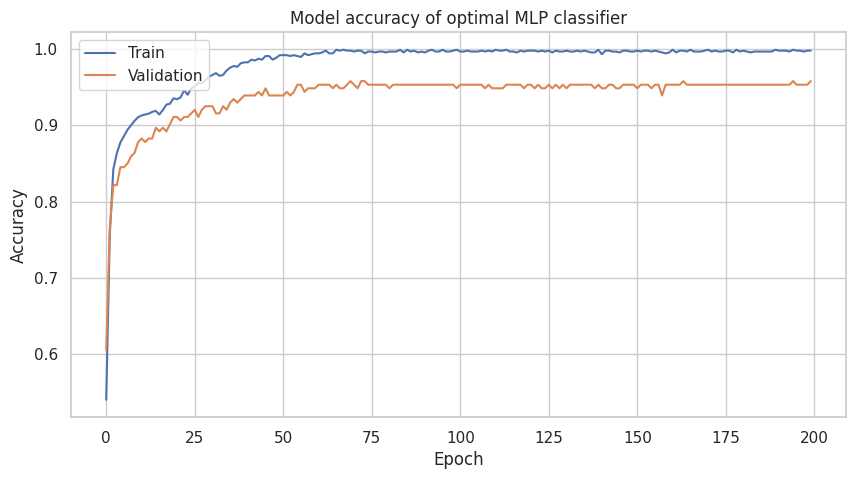

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy of optimal MLP classifier')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.savefig("Model_accuracy_of_optimal_MLP_classifier", dpi=600)

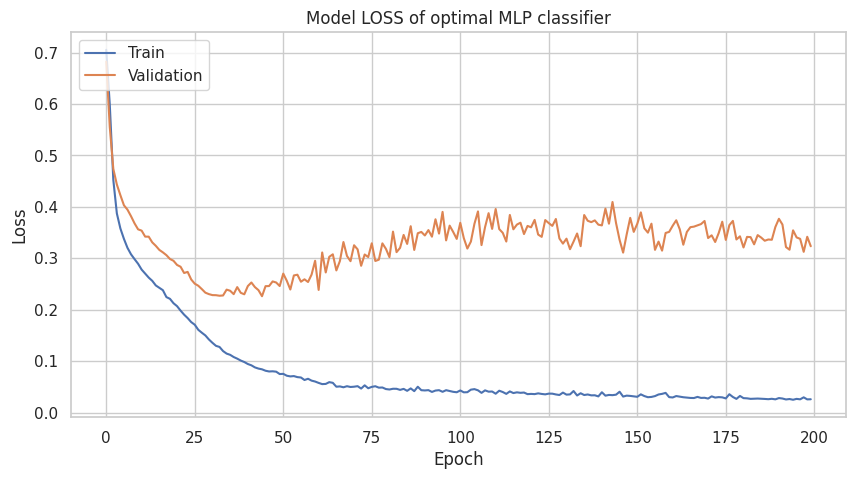

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model LOSS of optimal MLP classifier')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.savefig("Model_LOSS_of_optimal_MLP_classifier", dpi=600)

# SVC (Suppprt Vector Classifier)

### Read the data and initial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Strandardization and checking it

In [ ]:
from sklearn.preprocessing import StandardScaler
# StandardScaler
scaler = StandardScaler()
X_train_valid = scaler.fit_transform(X_train_valid)         # Fit and Transfrom on the train data
X_test        = scaler.transform(X_test)                    # Just Transfrom on the test data (do not fit on test data)

In [ ]:
# Calculate mean and standard deviation for train_valid data
mean_train_valid = X_train_valid.mean(axis=0)
std_train_valid = X_train_valid.std(axis=0)

# Calculate mean and standard deviation for test data
mean_test = X_test.mean(axis=0)
std_test = X_test.std(axis=0)

print("Mean and Standard Deviation for Train_Valid Data:")
print("Mean: ", mean_train_valid)
print("Standard Deviation: ", std_train_valid)

print("\nMean and Standard Deviation for Test Data:")
print("Mean: ", mean_test)
print("Standard Deviation: ", std_test)


print("")
print("")

print("The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT")
print("The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT")
print("")
print("The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT")
print("The STD  of all variables in the test must not necessary be a, CHECKED, CORRECT")

print("")
print("")
print("")

Mean and Standard Deviation for Train_Valid Data:
Mean:  [-3.34530478e-17  3.34530478e-18  2.50897859e-17 -1.33812191e-17
 -1.50538715e-17  0.00000000e+00  7.02514004e-17 -2.67624383e-17
  2.50897859e-17  6.69060956e-18  4.68342670e-17 -4.59979408e-17
 -8.36326196e-18]
Standard Deviation:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Mean and Standard Deviation for Test Data:
Mean:  [-0.0640455  -0.01302773  0.00378777 -0.06161407  0.06215734 -0.0166319
  0.05181564  0.06902623  0.0506676   0.1067042   0.00499926 -0.06592597
  0.13900071]
Standard Deviation:  [0.88867094 1.00538418 0.98202875 0.94774487 1.15717863 0.98330748
 1.01637713 0.93575103 1.01694394 1.10190155 1.03822177 0.97392313
 0.93661978]


The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT
The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT

The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT
The STD  of all variables in the test must not necessary be a

### SVC itself + its accuracy

In [ ]:
# Considering some parameters for checking the optimal support vector classifier
param_grid = {
    'C'       : [0.1, 1, 10],
    'gamma'   : [0.001, 0.01, 0.1],
    'kernel'  : ['rbf', 'poly', 'linear'],
    # These are the parameters to consider for optimal solution using GridSearch
}


# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(SVC(random_state=42), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy

# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using SVC (Support Vector Classifier)")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using SVC (Support Vector Classifier)
After using GridSearchCV with 5-fold cross validation we reach        100.0%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}




### Confusion Matrix of SVC

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       139

    accuracy                           1.00       266
   macro avg       1.00      1.00      1.00       266
weighted avg       1.00      1.00      1.00       266


Confusion Matrix:
[[127   0]
 [  0 139]]


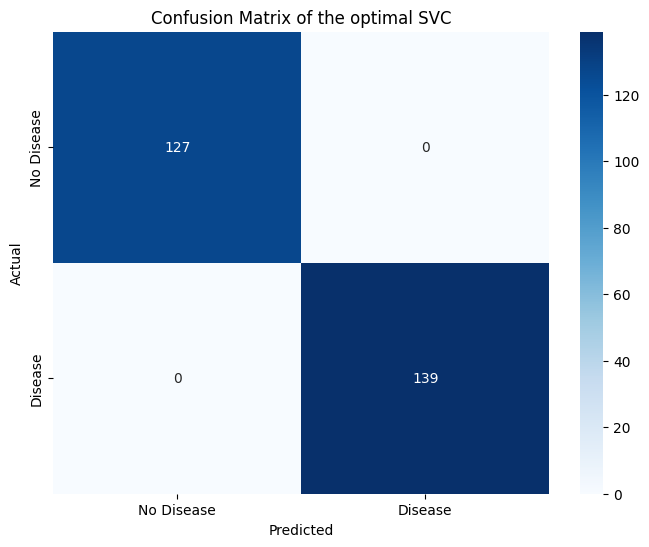

In [ ]:
# Confusion Matrix of this SVC (Support Vector Classifer)
# =========================================================================================
# Train the model
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal SVC')
plt.savefig("Confusion_Matrix_of_the_optimal_SVC_test_data", dpi=600)
plt.show()



Confusion matrix, without normalization
Normalized confusion matrix


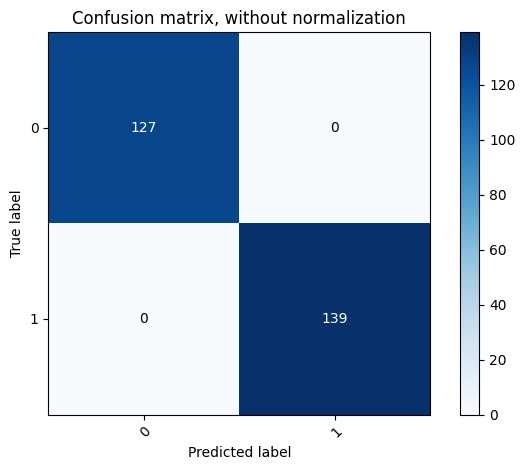

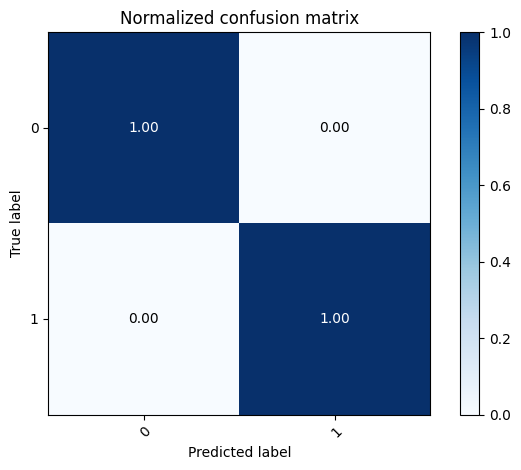

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

# KNN

### Reading the data and intial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Standaradization

In [ ]:
from sklearn.preprocessing import StandardScaler
# StandardScaler
scaler = StandardScaler()
X_train_valid = scaler.fit_transform(X_train_valid)         # Fit and Transfrom on the train data
X_test        = scaler.transform(X_test)                    # Just Transfrom on the test data (do not fit on test data)

In [ ]:
# Calculate mean and standard deviation for train_valid data
mean_train_valid = X_train_valid.mean(axis=0)
std_train_valid = X_train_valid.std(axis=0)

# Calculate mean and standard deviation for test data
mean_test = X_test.mean(axis=0)
std_test = X_test.std(axis=0)

print("Mean and Standard Deviation for Train_Valid Data:")
print("Mean: ", mean_train_valid)
print("Standard Deviation: ", std_train_valid)

print("\nMean and Standard Deviation for Test Data:")
print("Mean: ", mean_test)
print("Standard Deviation: ", std_test)


print("")
print("")

print("The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT")
print("The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT")
print("")
print("The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT")
print("The STD  of all variables in the test must not necessary be a, CHECKED, CORRECT")

print("")
print("")
print("")

Mean and Standard Deviation for Train_Valid Data:
Mean:  [-1.00359143e-17  3.34530478e-18  2.42534597e-17 -1.00359143e-17
 -1.50538715e-17  0.00000000e+00  1.67265239e-17 -2.00718287e-17
  2.50897859e-17  3.34530478e-18  4.68342670e-17 -3.26167216e-17
 -8.36326196e-18]
Standard Deviation:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Mean and Standard Deviation for Test Data:
Mean:  [-0.0640455  -0.01302773  0.00378777 -0.06161407  0.06215734 -0.0166319
  0.05181564  0.06902623  0.0506676   0.1067042   0.00499926 -0.06592597
  0.13900071]
Standard Deviation:  [0.88867094 1.00538418 0.98202875 0.94774487 1.15717863 0.98330748
 1.01637713 0.93575103 1.01694394 1.10190155 1.03822177 0.97392313
 0.93661978]


The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT
The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT

The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT
The STD  of all variables in the test must not necessary be a

### KNN Classifier + its accuracy

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Define the parameter grid
param_grid = {
    'n_neighbors': np.arange(1, 15)
}


# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy

# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using KNNC (KNeighborsClassifier)")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using KNNC (KNeighborsClassifier)
After using GridSearchCV with 5-fold cross validation we reach        100.0%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'n_neighbors': 1}




### Confusion matrix of KNN

In [ ]:
# Train and evaluate a K-Nearest Neighbors model

# Train the model
grid_search_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)


knn_model = KNeighborsClassifier(n_neighbors=1)     # Since we foudn 1 to be optimal
knn_model.fit(X_train_valid, Y_train_valid)
y_pred_knn = knn_model.predict(X_test)
print("K-Nearest Neighbors")
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))
print(f"best params: {parameters}")

K-Nearest Neighbors
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       139

    accuracy                           1.00       266
   macro avg       1.00      1.00      1.00       266
weighted avg       1.00      1.00      1.00       266

[[127   0]
 [  0 139]]
best params: {'n_neighbors': 1}



Confusion Matrix:
[[127   0]
 [  0 139]]


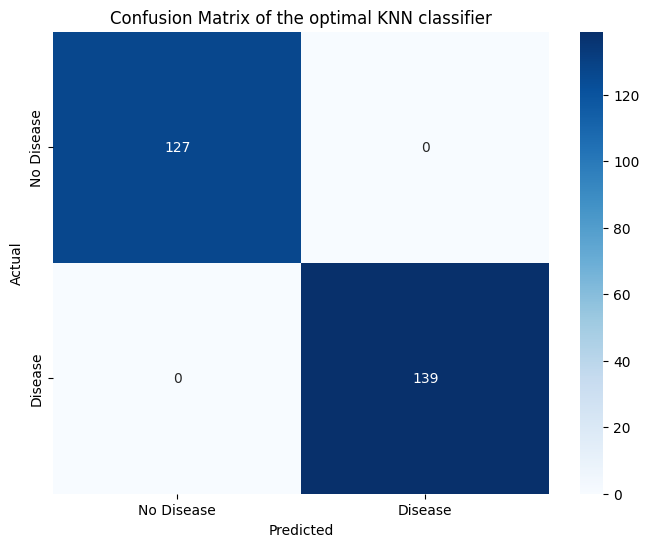

In [ ]:
print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal KNN classifier')
plt.savefig("Confusion_Matrix_of_the_optimal_KNN_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


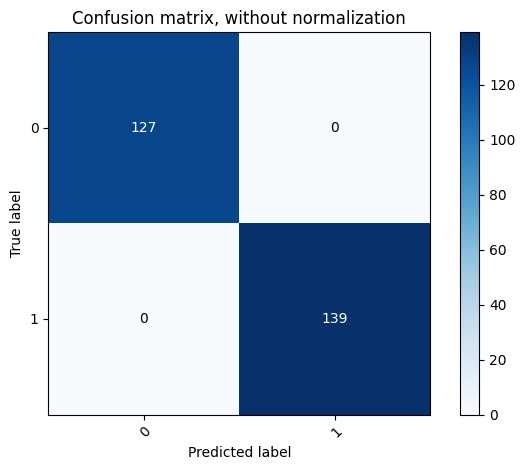

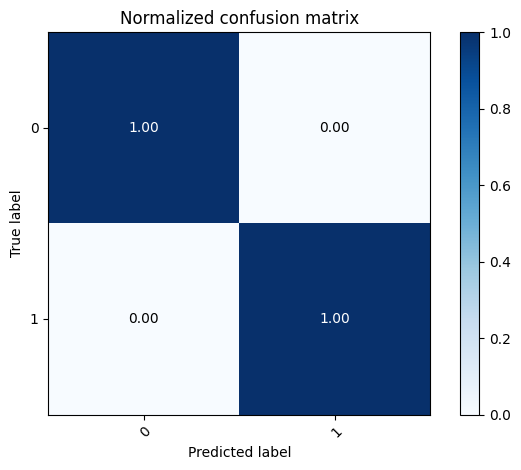

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

### Assessing the impact of K

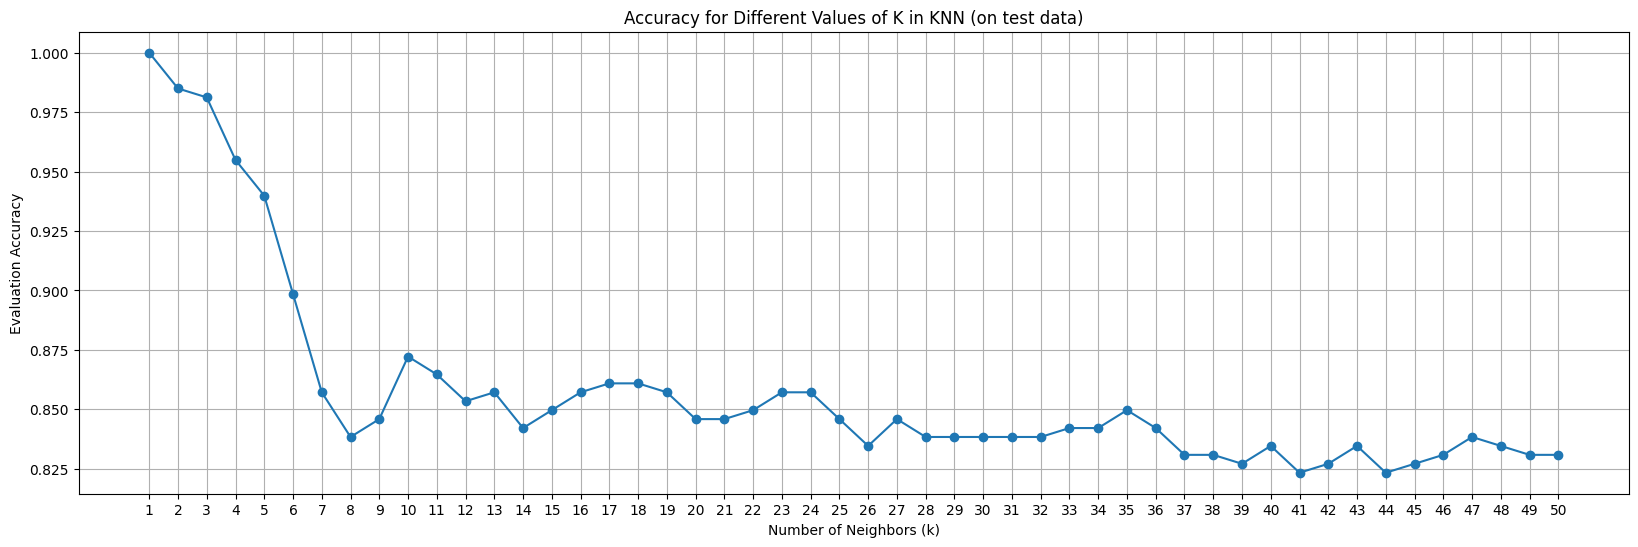

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define the range of k values to test
k_values = range(1, 51)
accuracies = []

# Train and evaluate KNN for each k value
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_valid, Y_train_valid)       # Replace with your actual training data
    Y_pred = knn_model.predict(X_test)                # Replace with your actual test data
    accuracy = accuracy_score(Y_test, Y_pred)         # Calculate accuracy
    accuracies.append(accuracy)

# Plot the mean error for each k value
plt.figure(figsize=(20,6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Evaluation Accuracy')
plt.title('Accuracy for Different Values of K in KNN (on test data)')
plt.xticks(k_values)
plt.grid(True)
plt.savefig("Accuracy_for_Different_Values_of_K_in_KNN", dpi=600)
plt.show()


# RFC (Random Forest Classifier)

### Reading the data and initial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### DT, RF, Bagging, XGB => They are not sensitive to distance. Therefore, scaling is not needed.

In [ ]:
# Decision Tree, Random Forest, Bagging, XGBoost, and other methods which are solely based on DT, do not required scaling.

### Random Forest Classifier + its accuracy

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Define the parameter grid to search over
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [3, 5, 10, 11, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(RandomForestClassifier(), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy

# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using RFC (Random Forest Classifier)")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using RFC (Random Forest Classifier)
After using GridSearchCV with 5-fold cross validation we reach        100.0%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}




### Confusion matrix of the optimal RFC (Random Forest Classifier)

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       139

    accuracy                           1.00       266
   macro avg       1.00      1.00      1.00       266
weighted avg       1.00      1.00      1.00       266


Confusion Matrix:
[[127   0]
 [  0 139]]


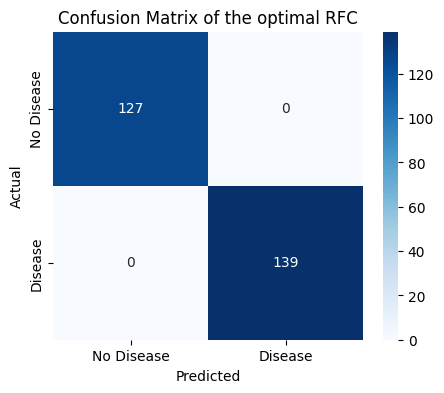

In [ ]:
# Confusion Matrix of this RFC (Random Forest Classifer)
# =========================================================================================
# Train the model
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal RFC')
plt.savefig("Confusion_Matrix_of_the_optimal_RFC_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


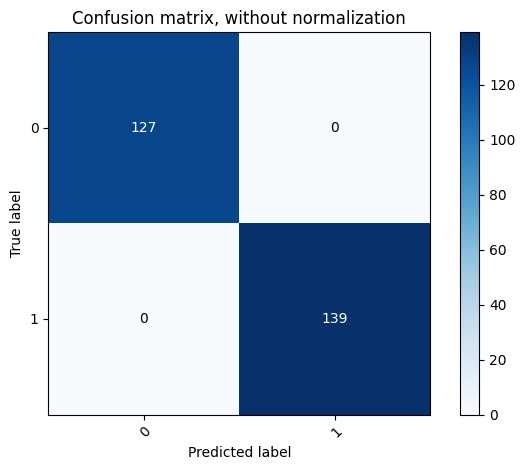

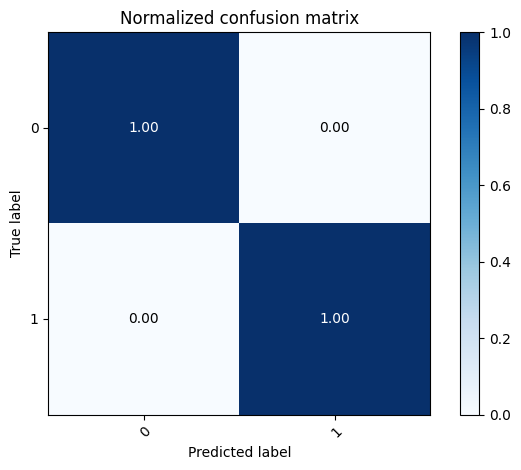

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

# AdaBoost

### Reading the data and initial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### DT, RF, Bagging, XGB => They are not sensitive to distance. Therefore, scaling is not needed.

In [ ]:
# Decision Tree, Random Forest, Bagging, Adaboost and other methods which are solely based on DT, do not required scaling.

### Adaboost Classifier + its accuracy

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
# Define the parameter grid to search over
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.1, 0.2, 0.5, 0.75, 1]               # NOTE: learning rate more than 1 is meaningless. It's rubbish
}


# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(AdaBoostClassifier(), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy

# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using AdaBoost Classification")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using AdaBoost Classification
After using GridSearchCV with 5-fold cross validation we reach        96.61654135338345%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'learning_rate': 1, 'n_estimators': 400}




### Adaboost Confusion Matrix

Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       127
           1       0.96      0.98      0.97       139

    accuracy                           0.97       266
   macro avg       0.97      0.97      0.97       266
weighted avg       0.97      0.97      0.97       266


Confusion Matrix:
[[121   6]
 [  3 136]]


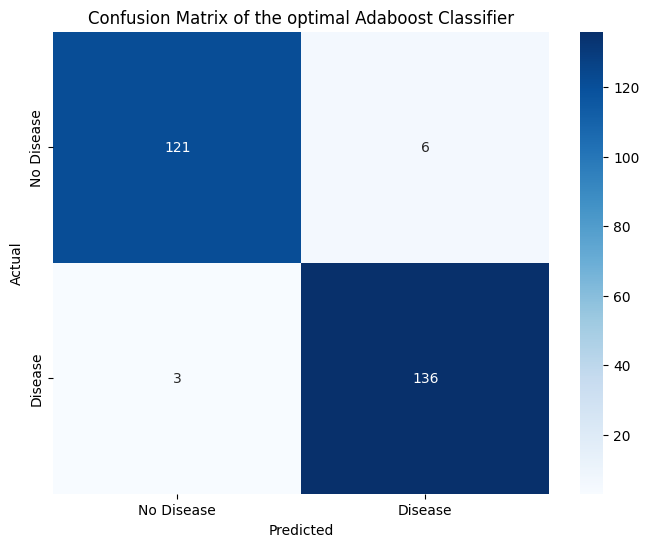

In [ ]:
# Confusion Matrix of this Adaboost classifier (AdaBoost Classifer)
# =========================================================================================
# Train the model
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal Adaboost Classifier')
plt.savefig("Confusion_Matrix_of_the_optimal_Adaboost_classifier_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


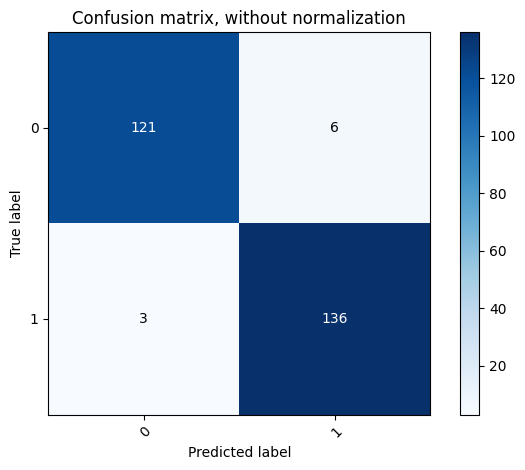

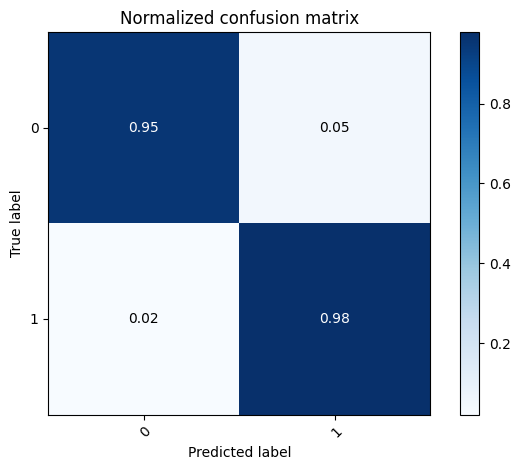

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

### Assessing the impact of LR when n_estimator is constant

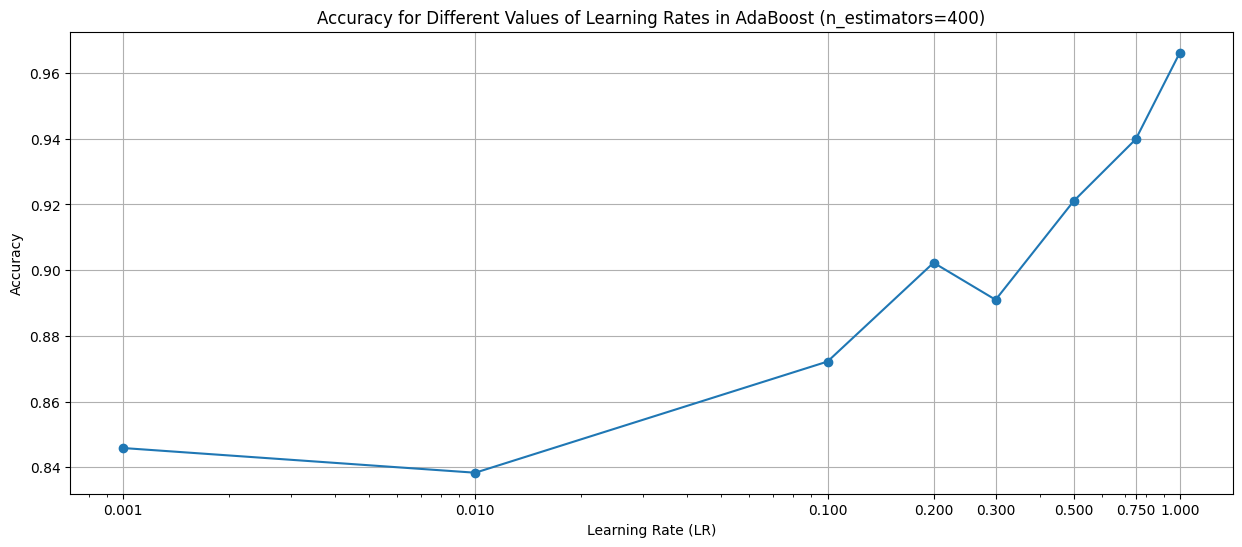

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Define the range of learning rates to test
LRs = [0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 0.75, 1]

# Train and evaluate AdaBoost for each learning rate
accuracies = []
for LR in LRs:
    adaboost_model = AdaBoostClassifier(learning_rate=LR, n_estimators=400)
    adaboost_model.fit(X_train_valid, Y_train_valid)  # Replace with your actual training data
    Y_pred = adaboost_model.predict(X_test)          # Replace with your actual test data
    accuracy = accuracy_score(Y_test, Y_pred)        # Calculate accuracy
    accuracies.append(accuracy)

# Plot the accuracy for different learning rates
plt.figure(figsize=(15, 6))
plt.semilogx(LRs, accuracies, marker='o')  # Use semilogx for logarithmic x-axis
plt.xlabel('Learning Rate (LR)')
plt.ylabel('Accuracy')
plt.title('Accuracy for Different Values of Learning Rates in AdaBoost (n_estimators=400)')
plt.grid(True)
plt.xticks(LRs, labels=[f'{LR:.3f}' for LR in LRs])  # Show real values on x-axis
plt.savefig("Accuracy_for_Different_Values_of_LRS_in_Adaboost_when_n_estimators=300.png", dpi=600)
plt.show()


# XGBoost

### Read the data and intial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### DT, RF, Bagging, XGB => They are not sensitive to distance. Therefore, scaling is not needed.

In [ ]:
# Decision Tree, Random Forest, Bagging, Adaboost and other methods which are solely based on DT, do not required scaling.

### XGBoost Classifier + its accuracy

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# Define the parameter grid to search
param_grid = {
    'learning_rate' : [0.001, 0.01, 0.1, 0.3, 0.5],
    'max_depth'     : [3, 5, 7],
    'n_estimators'  : [100, 200, 300]
}

# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(XGBClassifier(), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy

# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using XGBoost classifier")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using XGBoost classifier
After using GridSearchCV with 5-fold cross validation we reach        100.0%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}




### Confusion Matrix of XGBoost

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       139

    accuracy                           1.00       266
   macro avg       1.00      1.00      1.00       266
weighted avg       1.00      1.00      1.00       266


Confusion Matrix:
[[127   0]
 [  0 139]]


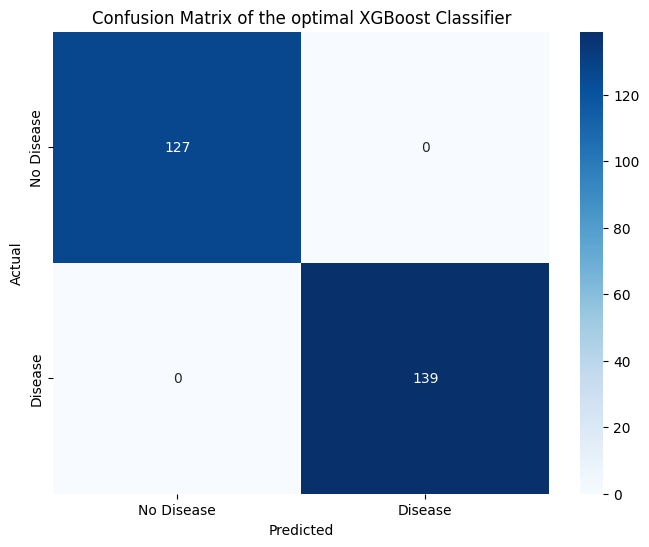

In [ ]:
# Confusion Matrix of this XGboost classifier
# =========================================================================================
# Train the model
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal XGBoost Classifier')
plt.savefig("Confusion_Matrix_of_the_optimal_XGBoost_classifier_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


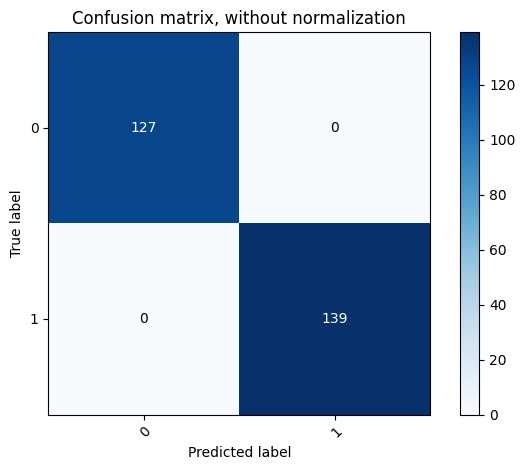

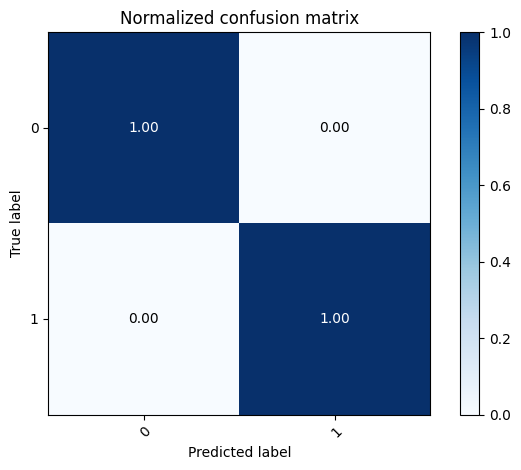

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

### Assessing the impact of learning rate on XGboost while n_estimators and max_depth are constant (good intutions)

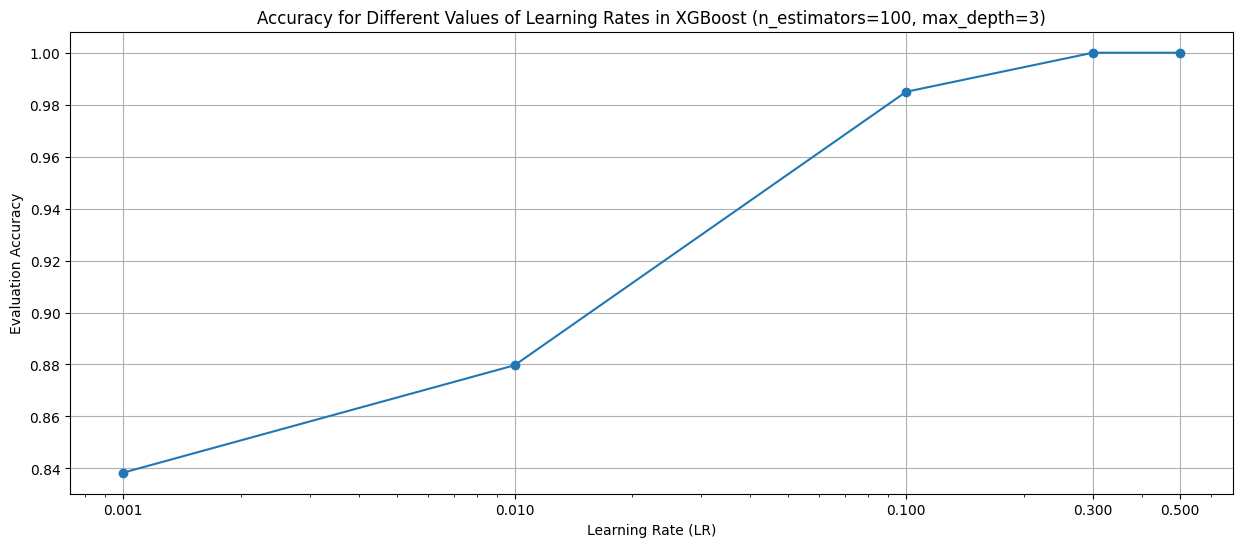

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Define the range of learning rates to test
LRs = [0.001, 0.01, 0.1, 0.3, 0.5]

# Train and evaluate AdaBoost for each learning rate
accuracies = []
for LR in LRs:
    XGboost_model = XGBClassifier(learning_rate=LR, n_estimators=200, max_depth=3)
    XGboost_model.fit(X_train_valid, Y_train_valid)      # Replace with your actual training data
    Y_pred = XGboost_model.predict(X_test)               # Replace with your actual test data
    accuracy = accuracy_score(Y_test, Y_pred)            # Calculate accuracy
    accuracies.append(accuracy)

# Plot the accuracy for different learning rates
plt.figure(figsize=(15, 6))
plt.semilogx(LRs, accuracies, marker='o')  # Use semilogx for logarithmic x-axis
plt.xlabel('Learning Rate (LR)')
plt.ylabel('Evaluation Accuracy')
plt.title('Accuracy for Different Values of Learning Rates in XGBoost (n_estimators=100, max_depth=3)')
plt.grid(True)
plt.xticks(LRs, labels=[f'{LR:.3f}' for LR in LRs])  # Show real values on x-axis
plt.savefig("Accuracy_for_Different_Values_of_LRS_in_XGboost_when_n_eestimators=100_and_max_depth=3_.png", dpi=600)
plt.show()

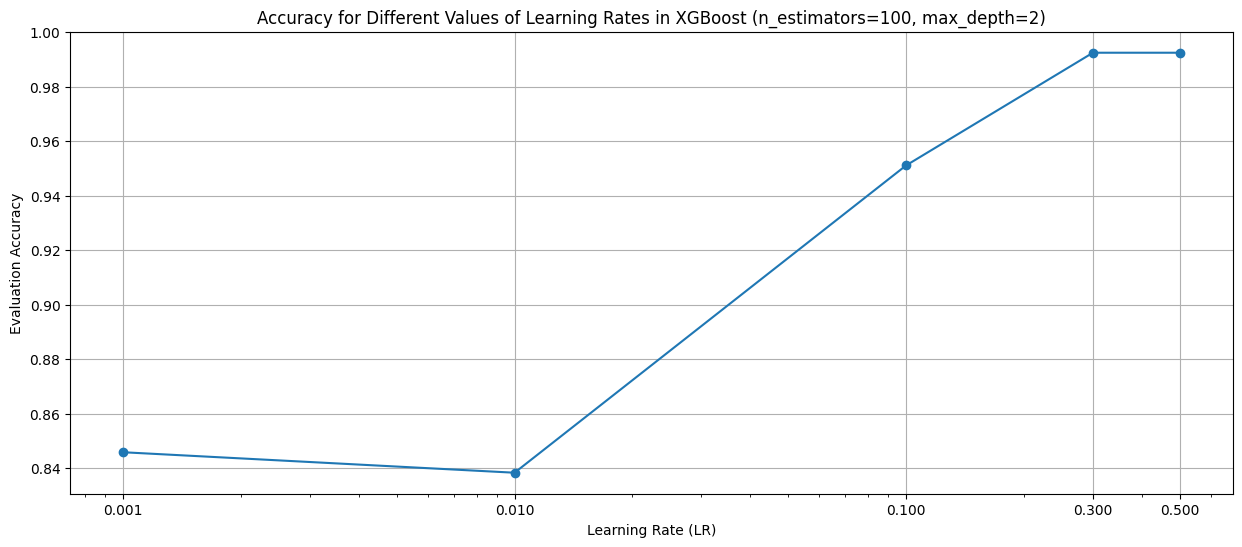

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Define the range of learning rates to test
LRs = [0.001, 0.01, 0.1, 0.3, 0.5]

# Train and evaluate AdaBoost for each learning rate
accuracies = []
for LR in LRs:
    XGboost_model = XGBClassifier(learning_rate=LR, n_estimators=200, max_depth=2)
    XGboost_model.fit(X_train_valid, Y_train_valid)      # Replace with your actual training data
    Y_pred = XGboost_model.predict(X_test)               # Replace with your actual test data
    accuracy = accuracy_score(Y_test, Y_pred)            # Calculate accuracy
    accuracies.append(accuracy)

# Plot the accuracy for different learning rates
plt.figure(figsize=(15, 6))
plt.semilogx(LRs, accuracies, marker='o')  # Use semilogx for logarithmic x-axis
plt.xlabel('Learning Rate (LR)')
plt.ylabel('Evaluation Accuracy')
plt.title('Accuracy for Different Values of Learning Rates in XGBoost (n_estimators=100, max_depth=2)')
plt.grid(True)
plt.xticks(LRs, labels=[f'{LR:.3f}' for LR in LRs])  # Show real values on x-axis
plt.savefig("Accuracy_for_Different_Values_of_LRS_in_XGboost_when_n_eestimators=100_and_max_depth=2_.png", dpi=600)
plt.show()

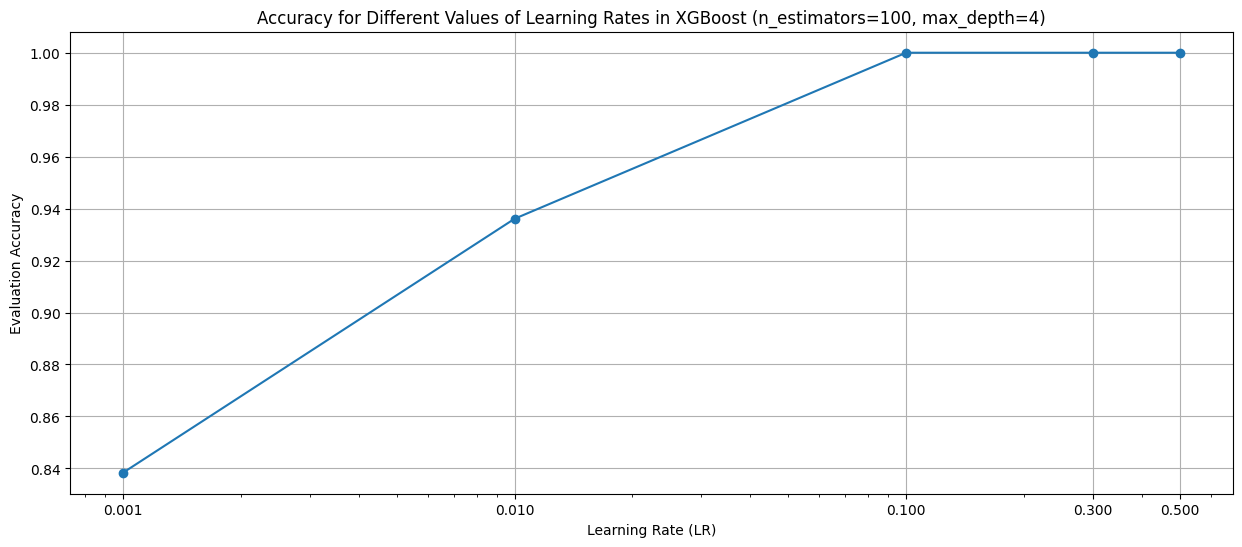

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Define the range of learning rates to test
LRs = [0.001, 0.01, 0.1, 0.3, 0.5]

# Train and evaluate AdaBoost for each learning rate
accuracies = []
for LR in LRs:
    XGboost_model = XGBClassifier(learning_rate=LR, n_estimators=200, max_depth=4)
    XGboost_model.fit(X_train_valid, Y_train_valid)      # Replace with your actual training data
    Y_pred = XGboost_model.predict(X_test)               # Replace with your actual test data
    accuracy = accuracy_score(Y_test, Y_pred)            # Calculate accuracy
    accuracies.append(accuracy)

# Plot the accuracy for different learning rates
plt.figure(figsize=(15, 6))
plt.semilogx(LRs, accuracies, marker='o')  # Use semilogx for logarithmic x-axis
plt.xlabel('Learning Rate (LR)')
plt.ylabel('Evaluation Accuracy')
plt.title('Accuracy for Different Values of Learning Rates in XGBoost (n_estimators=100, max_depth=4)')
plt.grid(True)
plt.xticks(LRs, labels=[f'{LR:.3f}' for LR in LRs])  # Show real values on x-axis
plt.savefig("Accuracy_for_Different_Values_of_LRS_in_XGboost_when_n_eestimators=100_and_max_depth=4_.png", dpi=600)
plt.show()

# Bagging

### Read the data and initial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### DT, RF, Bagging, XGB => They are not sensitive to distance. Therefore, scaling is not needed.

In [ ]:
# Decision Tree, Random Forest, Bagging, Adaboost and other methods which are solely based on DT, do not required scaling.

### Bagging Classifier + its accuracy

In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
# Define the parameter grid to search
# Define the hyperparameters to search through
param_grid = {
    'n_estimators'  : [10, 20, 30],
    'max_samples'   : [0.5, 0.7, 0.9]
}

# K-fold Cross validation => 5-fold corss validation
cv = 5


# GridSearchCV
grid_search_cv = GridSearchCV(BaggingClassifier(), param_grid, cv=cv, scoring='accuracy')     # GridSearch + 5-fold cross validation


# Fit on train +  score on test
grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)                             # Fitting the model for 5-fold cross validation using grid_search_cv
parameters = grid_search_cv.best_params_                                      # This shows the parameters that lead to the best/optimal accuracy

# *** Model Evaluation ***
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using Bagging classifier")
print(f"After using GridSearchCV with 5-fold cross validation we reach        {test_score*100}%      accuracy on test (unseen) data")
print(f"The parameters that led to this accuracy were:                        {parameters}")
print("")
print("")

MODEL PERFORMANCE
Using Bagging classifier
After using GridSearchCV with 5-fold cross validation we reach        99.24812030075188%      accuracy on test (unseen) data
The parameters that led to this accuracy were:                        {'max_samples': 0.7, 'n_estimators': 30}




Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       127
           1       1.00      0.99      1.00       139

    accuracy                           1.00       266
   macro avg       1.00      1.00      1.00       266
weighted avg       1.00      1.00      1.00       266


Confusion Matrix:
[[127   0]
 [  1 138]]


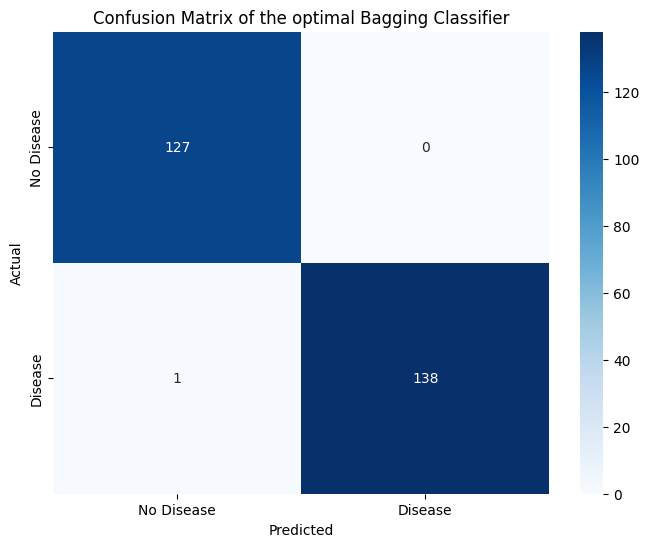

In [ ]:
# Confusion Matrix of this Bagging classifier
# =========================================================================================
# Train the model
grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))

print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal Bagging Classifier')
plt.savefig("Confusion_Matrix_of_the_optimal_Bagging_classifier_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


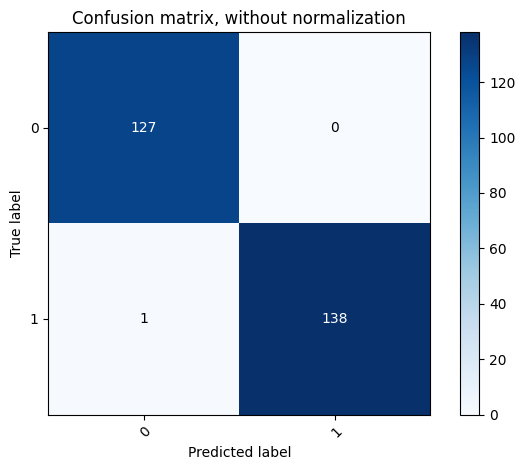

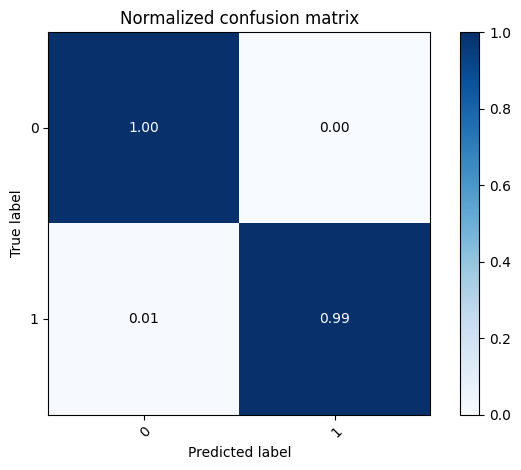

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

# Logestic Regression


### Reading the data and initial check

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Standaradization


##### logestic regression, SVM, KNN are sensitive to distances and require scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
# StandardScaler
scaler = StandardScaler()
X_train_valid = scaler.fit_transform(X_train_valid)         # Fit and Transfrom on the train data
X_test        = scaler.transform(X_test)                    # Just Transfrom on the test data (do not fit on test data)

In [ ]:
# Calculate mean and standard deviation for train_valid data
mean_train_valid = X_train_valid.mean(axis=0)
std_train_valid = X_train_valid.std(axis=0)

# Calculate mean and standard deviation for test data
mean_test = X_test.mean(axis=0)
std_test = X_test.std(axis=0)

print("Mean and Standard Deviation for Train_Valid Data:")
print("Mean: ", mean_train_valid)
print("Standard Deviation: ", std_train_valid)

print("\nMean and Standard Deviation for Test Data:")
print("Mean: ", mean_test)
print("Standard Deviation: ", std_test)


print("")
print("")

print("The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT")
print("The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT")
print("")
print("The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT")
print("The STD  of all variables in the test must not necessary be a, CHECKED, CORRECT")

print("")
print("")
print("")

Mean and Standard Deviation for Train_Valid Data:
Mean:  [-1.00359143e-17  3.34530478e-18  2.00718287e-17 -1.00359143e-17
 -1.33812191e-17  0.00000000e+00  1.67265239e-17 -1.33812191e-17
  2.50897859e-17  3.34530478e-18  4.68342670e-17 -3.01077430e-17
 -8.36326196e-18]
Standard Deviation:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Mean and Standard Deviation for Test Data:
Mean:  [-0.0640455  -0.01302773  0.00378777 -0.06161407  0.06215734 -0.0166319
  0.05181564  0.06902623  0.0506676   0.1067042   0.00499926 -0.06592597
  0.13900071]
Standard Deviation:  [0.88867094 1.00538418 0.98202875 0.94774487 1.15717863 0.98330748
 1.01637713 0.93575103 1.01694394 1.10190155 1.03822177 0.97392313
 0.93661978]


The MEAN of all variables in the train_valid must be 0, CHECKED, CORRECT
The STD  of all variables in the train_valid must be 1, CHECKED, CORRECT

The MEAN of all variables in the test must not necessary be 0, CHECKED, CORRECT
The STD  of all variables in the test must not necessary be a

### Logestic regression and its accuracy

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 0.2, 0.5, 0.75, 1, 1.33, 2, 5, 10, 100],
}

# K-fold Cross validation => 5-fold cross validation
cv = 5

# GridSearchCV
grid_search_cv = GridSearchCV(LogisticRegression(), param_grid, cv=cv, scoring='accuracy')


import warnings
# Fit on train + score on test
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # Suppress any warnings during fitting
    grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)
parameters = grid_search_cv.best_params_

# Model Evaluation
print("MODEL PERFORMANCE")
print("====================================================================================================================================")
print("Using logistic regression")
print(f"After using GridSearchCV with 5-fold cross validation, we achieve     {test_score*100:.2f}%         accuracy on test (unseen) data.")
print(f"The optimal hyperparameters are:                                      {parameters}")


MODEL PERFORMANCE
Using logistic regression
After using GridSearchCV with 5-fold cross validation, we achieve     80.83%         accuracy on test (unseen) data.
The optimal hyperparameters are:                                      {'C': 0.1}


### Confusion Matrix of logestic regression

Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       127
           1       0.79      0.86      0.82       139

    accuracy                           0.81       266
   macro avg       0.81      0.81      0.81       266
weighted avg       0.81      0.81      0.81       266


Confusion Matrix:
[[ 95  32]
 [ 19 120]]


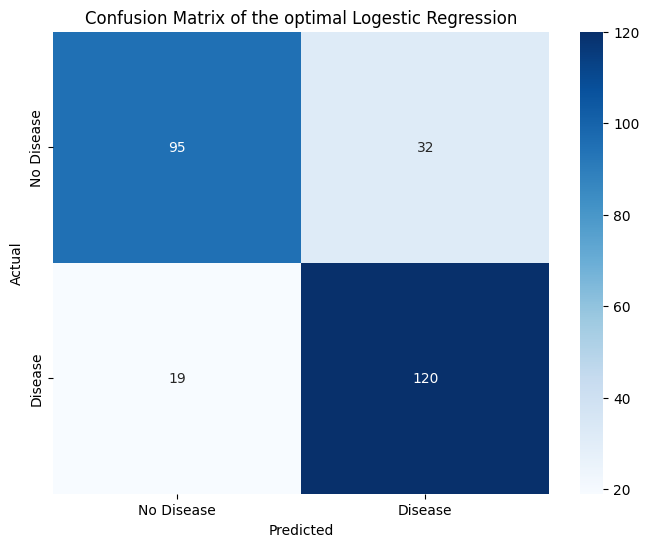

In [ ]:
# Confusion Matrix of this logestic regression
# =========================================================================================
# Train the model
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # Suppress any warnings during fitting
    grid_search_cv.fit(X_train_valid, Y_train_valid)
# Make predictions
Y_pred = grid_search_cv.predict(X_test)


# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')


print('\nClassification Report:')
print(classification_report(Y_test, Y_pred))


print('\nConfusion Matrix:')
cm = confusion_matrix(Y_test, Y_pred)
print(cm)


import warnings
# Fit on train + score on test
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # Suppress any warnings during fitting
    grid_search_cv.fit(X_train_valid, Y_train_valid)
test_score = grid_search_cv.score(X_test, Y_test)
parameters = grid_search_cv.best_params_


# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the optimal Logestic Regression')
plt.savefig("Confusion_Matrix_of_the_optimal_logestic_regression_test_data", dpi=600)
plt.show()

Confusion matrix, without normalization
Normalized confusion matrix


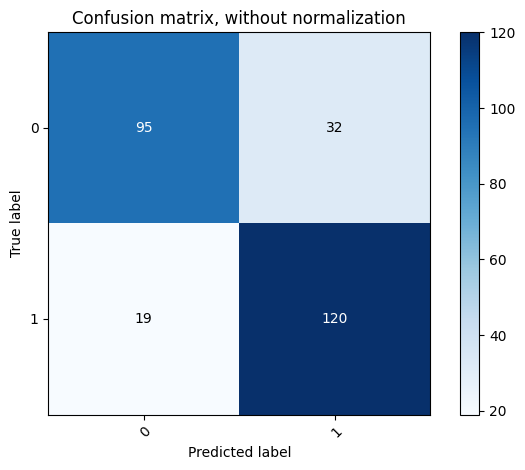

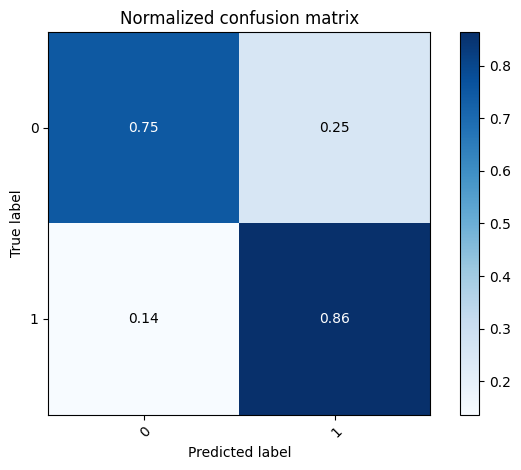

In [ ]:
# Plot non-normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(Y_test, Y_pred, classes=['0', '1'], normalize=True,
                      title='Normalized confusion matrix')

plt.show()

### Assessing the impact of C while other are constant

# Comparison between different models in their **optimal** version (regarding accuracy)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
# Function to train and evaluate a model
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    return accuracy, report

In [ ]:
# Initialize models in the ***OPTIMAL*** format
models = {
    'Decision Tree'                   : DecisionTreeClassifier(max_depth=11, min_samples_leaf=3, min_samples_split=7),
    'Support Vector Machine (SVM)'    : SVC(C=10, gamma=0.1, kernel="rbf"),
    'K-Nearest Neighbors (KNN)'       : KNeighborsClassifier(n_neighbors=1),
    'Random Forest'                   : RandomForestClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50),
    'AdaBoost'                        : AdaBoostClassifier(learning_rate=1, n_estimators=400),
    'Bagging'                         : BaggingClassifier(max_samples=0.7, n_estimators=20),
    'XGBoost'                         : XGBClassifier(learning_rate=0.3, max_depth=3, n_estimators=200),
    'Logistic Regression'             : LogisticRegression(C=0.2)
}

# We set the models based on the optimal hyperparameters

In [ ]:
# Evaluate each model
results = {}
for name, model in models.items():
    accuracy, report = evaluate_model(model, X_train_valid, Y_train_valid, X_test, Y_test)
    results[name] = {'accuracy': accuracy, 'report': report}

In [ ]:
# Print results
for name, result in results.items():
    print(f"{name}:")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Classification Report:\n{pd.DataFrame(result['report']).transpose()}\n")

Decision Tree:
Accuracy: 0.9511
Classification Report:
              precision    recall  f1-score     support
0              0.931818  0.968504  0.949807  127.000000
1              0.970149  0.935252  0.952381  139.000000
accuracy       0.951128  0.951128  0.951128    0.951128
macro avg      0.950984  0.951878  0.951094  266.000000
weighted avg   0.951848  0.951128  0.951152  266.000000

Support Vector Machine (SVM):
Accuracy: 1.0000
Classification Report:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0    127.0
1                   1.0     1.0       1.0    139.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0    266.0
weighted avg        1.0     1.0       1.0    266.0

K-Nearest Neighbors (KNN):
Accuracy: 1.0000
Classification Report:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0    127.0
1                   1.0     1.0       1.0    139.0
accuracy   

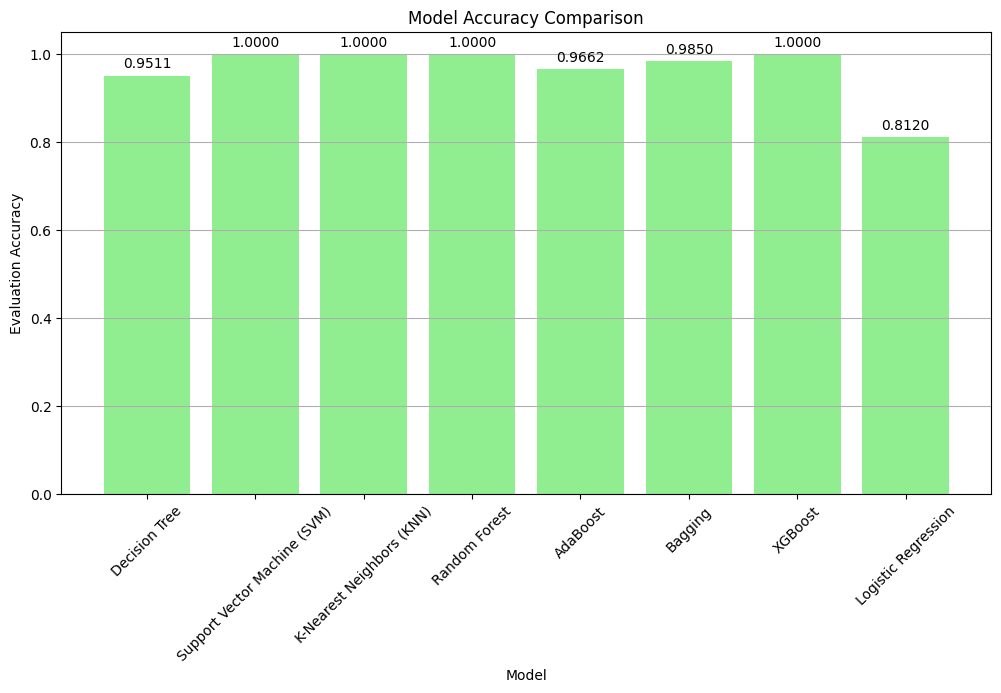

In [ ]:
# Plotting accuracies for comparison
accuracies = [result['accuracy'] for result in results.values()]
model_names = list(results.keys())

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color='lightgreen')
plt.xlabel('Model')
plt.ylabel('Evaluation Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.savefig("Model_Accuracy_Comparison", dpi=600)

plt.show()

##### NOTE => We have not included MLP in this chart as it is DL, not ML. Yet, its accuracy was high and approximately 0.985

In [ ]:

# Positive and negative points
positive_negative_points = {
    'Decision Tree': {
        'positive': 'Easy to interpret and visualize, handles non-linear data well',
        'negative': 'Prone to overfitting, less stable'
    },
    'Support Vector Machine (SVM)': {
        'positive': 'Effective in high-dimensional spaces, robust to overfitting',
        'negative': 'Memory intensive, can be slow for large datasets'
    },
    'K-Nearest Neighbors (KNN)': {
        'positive': 'Simple to implement, no training phase',
        'negative': 'Computationally expensive during prediction, sensitive to irrelevant features'
    },
    'Random Forest': {
        'positive': 'Reduces overfitting, handles large datasets well',
        'negative': 'Less interpretable, can be slower'
    },
    'AdaBoost': {
        'positive': 'Combines multiple weak learners, often improves accuracy',
        'negative': 'Sensitive to noisy data, requires careful tuning'
    },
    'Bagging': {
        'positive': 'Reduces variance, works well with high variance algorithms',
        'negative': 'Less effective on stable models, can be computationally intensive'
    },
    'XGBoost': {
        'positive': 'High performance, handles missing values well, feature importance',
        'negative': 'Complex, requires significant parameter tuning'
    },
    'Logistic Regression': {
        'positive': 'Simple and interpretable, works well for binary classification',
        'negative': 'Assumes linear relationship, can be less accurate for complex data'
    }
}

# Print positive and negative points for each model
for name, points in positive_negative_points.items():
    print(f"{name}:")
    print(f"Positive: {points['positive']}")
    print(f"Negative: {points['negative']}\n")

Decision Tree:
Positive: Easy to interpret and visualize, handles non-linear data well
Negative: Prone to overfitting, less stable

Support Vector Machine (SVM):
Positive: Effective in high-dimensional spaces, robust to overfitting
Negative: Memory intensive, can be slow for large datasets

K-Nearest Neighbors (KNN):
Positive: Simple to implement, no training phase
Negative: Computationally expensive during prediction, sensitive to irrelevant features

Random Forest:
Positive: Reduces overfitting, handles large datasets well
Negative: Less interpretable, can be slower

AdaBoost:
Positive: Combines multiple weak learners, often improves accuracy
Negative: Sensitive to noisy data, requires careful tuning

Bagging:
Positive: Reduces variance, works well with high variance algorithms
Negative: Less effective on stable models, can be computationally intensive

XGBoost:
Positive: High performance, handles missing values well, feature importance
Negative: Complex, requires significant paramet

# Comparison between different models in their **optimal** format (regarding precision and recall and f1 score)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Initialize models in the ***OPTIMAL*** format
models = {
    'Decision Tree'                   : DecisionTreeClassifier(max_depth=11, min_samples_leaf=3, min_samples_split=7),
    'Support Vector Machine (SVM)'    : SVC(C=10, gamma=0.1, kernel="rbf"),
    'K-Nearest Neighbors (KNN)'       : KNeighborsClassifier(n_neighbors=1),
    'Random Forest'                   : RandomForestClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50),
    'AdaBoost'                        : AdaBoostClassifier(learning_rate=1, n_estimators=400),
    'Bagging'                         : BaggingClassifier(max_samples=0.7, n_estimators=20),
    'XGBoost'                         : XGBClassifier(learning_rate=0.3, max_depth=3, n_estimators=200),
    'Logistic Regression'             : LogisticRegression(C=0.2)
}

# We set the models based on the optimal hyperparameters

In [ ]:
# Plotting metrics for each class using Seaborn
sns.set(style="whitegrid")

for metric, data in metrics_data.items():
    data = data.astype(float).reset_index().melt(id_vars='index')
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(x='index', y='value', hue='variable', data=data, palette='Set2')
    plt.title(f'{metric.capitalize()} Comparison for Each Model')
    plt.xlabel('Class')
    plt.ylabel(metric.capitalize())
    plt.xticks(rotation=45)
    plt.legend(title='Model')

    # Add numbers on top of bars
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points')

    plt.show()

# Overall metrics plot
overall_data = pd.DataFrame(index=overall_metrics, columns=models.keys())

for model_name, result in results.items():
    overall_data.loc['accuracy', model_name] = result['accuracy']
    for metric in overall_metrics[1:]:
        for score in metrics:
            overall_data.loc[f'{metric} {score}', model_name] = result['report'][metric][score]

overall_data = overall_data.astype(float).reset_index().melt(id_vars='index')

# # Plotting overall metrics using Seaborn
# plt.figure(figsize=(14, 8))
# ax = sns.barplot(x='index', y='value', hue='variable', data=overall_data, palette='Set2')
# plt.title('Overall Metrics Comparison for Each Model')
# plt.xlabel('Metric')
# plt.ylabel('Score')
# plt.xticks(rotation=45)
# plt.legend(title='Model')

# # Add numbers on top of bars
# for p in ax.patches:
#     ax.annotate(format(p.get_height(), '.2f'),
#                 (p.get_x() + p.get_width() / 2., p.get_height()),
#                 ha = 'center', va = 'center',
#                 xytext = (0, 10),
#                 textcoords = 'offset points')

plt.show()


NameError: name 'metrics_data' is not defined

# Important note regarding comparison

### The comparison is done using optimal models. This is why their performance is quite similar. Nonethless, if you run the models in their default mode (not optimal mode - no hyperparameter tuning), the results would be compeletely different

# Dendrogram (can be linked to clustering)

In [ ]:
df_imputed

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,163,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
1324,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
1325,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
1326,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.shape

(1328, 14)

In [ ]:
df.drop(columns=["target"], inplace=True)      # These are only the predicitive variables, target is removed, 13 features

In [ ]:
df.shape

(1328, 13)

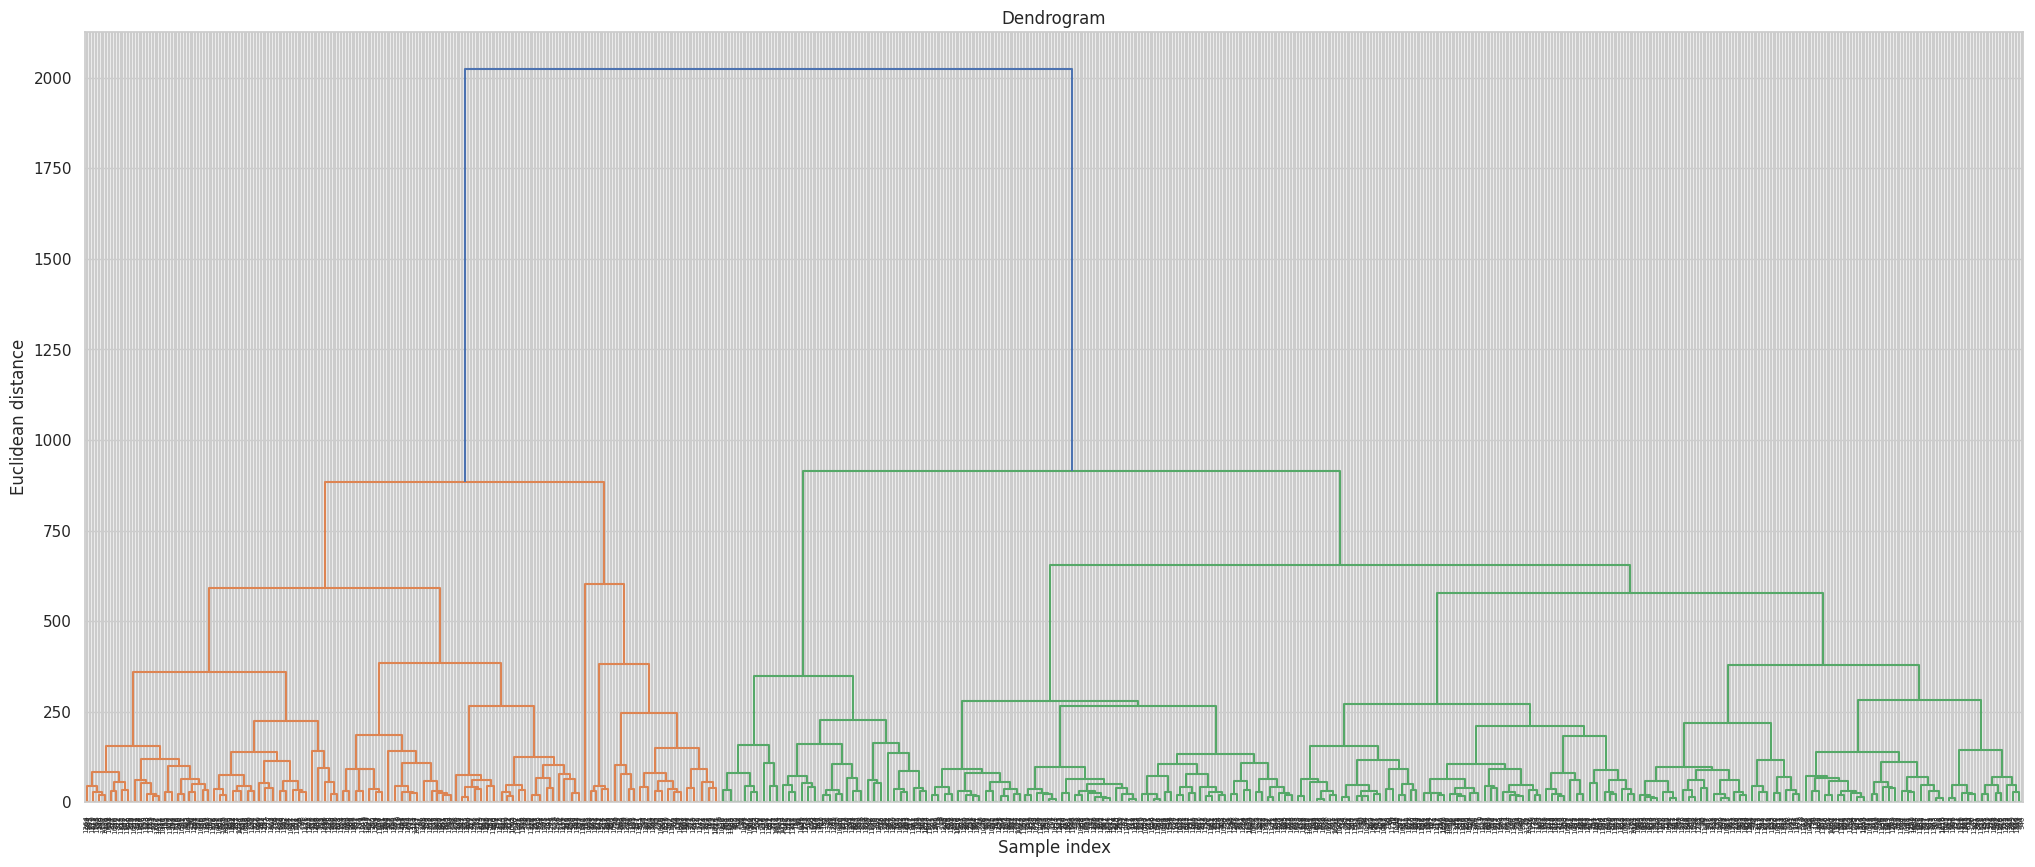

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

# Generate the linkage matrix
Z = linkage(df, 'ward')

# Create a new figure
fig = plt.figure(figsize=(25, 10))

# Create the dendrogram
dn = dendrogram(Z)

plt.title('Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Euclidean distance')
plt.savefig("Dendorgram", dpi=600)
plt.show()

### NOTE: Dendorgram can provide useful insights for clustering. You can cut dendorgram from somwehere you like, somewhere which looks rational. I observed that 2, 4, and 8 are good numbers to cluster.

# Clustering

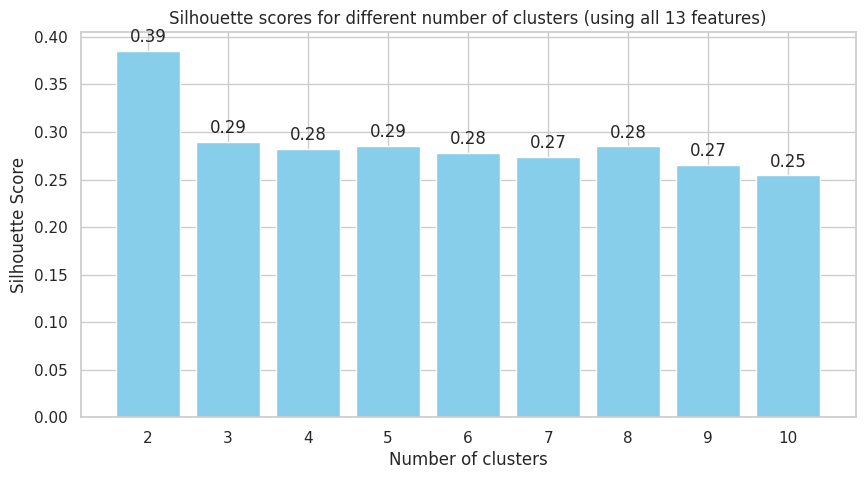

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Number of clusters
n_clusters = [2,3,4,5,6,7,8,9,10]

# Initialize an empty dictionary to hold the silhouette scores for each cluster
silhouette_scores = {}

# Perform KMeans clustering and compute silhouette scores
for n in n_clusters:
    kmeans = KMeans(n_clusters=n, n_init=10, random_state=42)
    kmeans.fit(df_imputed)
    labels = kmeans.labels_
    silhouette_scores[n] = silhouette_score(df_imputed, labels)

# Plot the silhouette scores
plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(silhouette_scores)), list(silhouette_scores.values()), align='center', color='skyblue')
plt.xticks(range(len(silhouette_scores)), list(silhouette_scores.keys()))
plt.title('Silhouette scores for different number of clusters (using all 13 features)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

# Display the silhouette scores on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), ha='center', va='bottom')

plt.show()

# PCA => 13 features to 2 features and then plotting 2D with K-means Clustering (K=2 since we had 2 classes in the dataset)

          PC1        PC2
0  -34.559650 -18.375855
1  -42.697108 -11.517348
2  -70.168141  29.936044
3  -41.965274  -7.404133
4   49.196768  43.232575
5    0.821271   8.559583
6   64.344842   6.461478
7   44.431025   6.153243
8    2.223498   2.528730
9   39.971232  30.631547
10 -96.681495  27.406680
11  94.517545   8.462917
12 -37.967123 -45.764934
13  52.617741  25.767044
14 -42.229670  -6.138598
15 -37.967123 -45.764934
16  62.054749 -10.804541
17  20.210765  38.196064
18  -2.896734 -16.207108
19 -34.553080 -12.911339


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


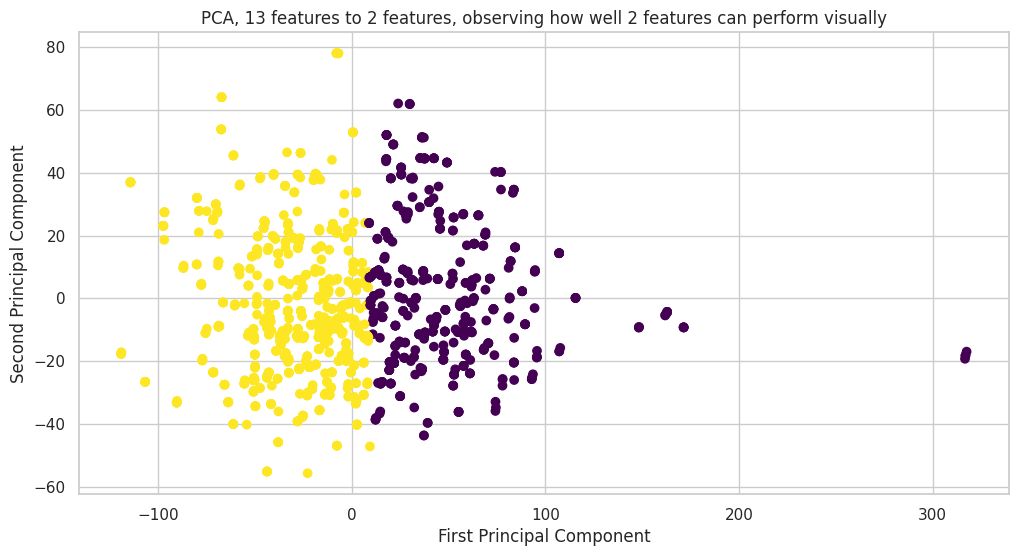

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply PCA and transform the data to 2D
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_imputed)

# Convert the result back to a pandas dataframe
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# Display the head of the transformed dataframe
print(df_pca.head(20))

# Perform KMeans clustering
kmeans = KMeans(n_clusters=2)
clusters = kmeans.fit_predict(df_pca)

# Plot the clusters
plt.figure(figsize=(12, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=clusters, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA, 13 features to 2 features, observing how well 2 features can perform visually')
plt.show()

# Clustering again. This time with 2 features that are derived from 13 features after applying PCA

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

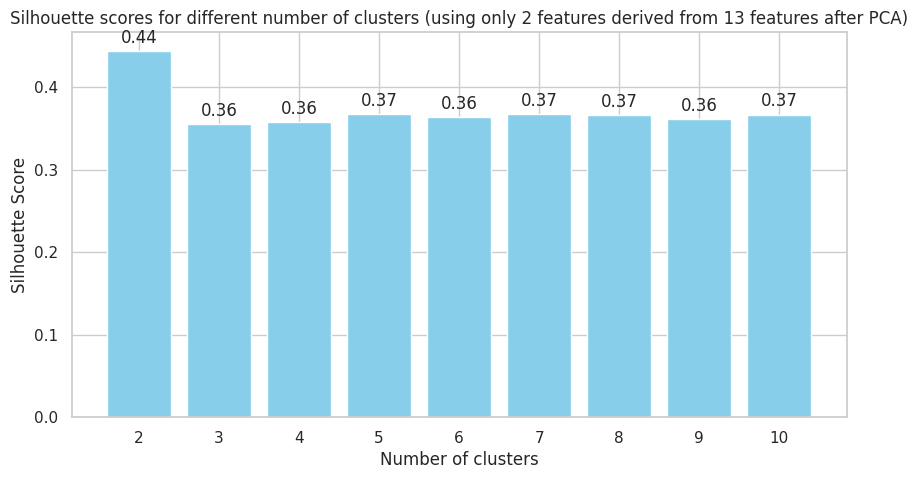

In [ ]:
from sklearn.metrics import silhouette_score

# Number of clusters
n_clusters = list(range(2, 11))

# Initialize an empty dictionary to hold the silhouette scores for each cluster
silhouette_scores = {}

# Perform KMeans clustering and compute silhouette scores
for n in n_clusters:
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(df_pca)
    labels = kmeans.labels_
    silhouette_scores[n] = silhouette_score(df_pca, labels)

# Plot the silhouette scores
plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(silhouette_scores)), list(silhouette_scores.values()), align='center', color='skyblue')
plt.xticks(range(len(silhouette_scores)), list(silhouette_scores.keys()))
plt.title('Silhouette scores for different number of clusters (using only 2 features derived from 13 features after PCA)')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

# Display the silhouette scores on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), ha='center', va='bottom')

plt.show()

### NOTE => Silohet criteria for all number have been improved after applying PCA (13->2)